In [2]:
import cv2
import os
import matplotlib.pyplot as plt

from __future__ import annotations
import numpy as np
from dataclasses import dataclass
from utils import tensor_to_video as t2v
from utils import dzida, make_rotating_rect_tensor

[DEBUG frame 0] BEV corners -> image:
 [[  120.           249.26666667]
 [  518.           249.26666667]
 [10220.           703.33333333]
 [-9680.           703.33333333]]
[DEBUG frame 0] bev.sum() = 860370
[DEBUG frame 299] BEV corners -> image:
 [[  120.           249.26666667]
 [  518.           249.26666667]
 [10220.           703.33333333]
 [-9680.           703.33333333]]
[DEBUG frame 299] bev.sum() = 520200
[DEBUG frame 0] BEV corners -> image:
 [[    66.66666667    257.66666667]
 [   570.8           257.66666667]
 [ 12860.           1123.33333333]
 [-12346.66666667   1123.33333333]]
[DEBUG frame 0] bev.sum() = 481440
[DEBUG frame 299] BEV corners -> image:
 [[    66.66666667    257.66666667]
 [   570.8           257.66666667]
 [ 12860.           1123.33333333]
 [-12346.66666667   1123.33333333]]
[DEBUG frame 299] bev.sum() = 897855


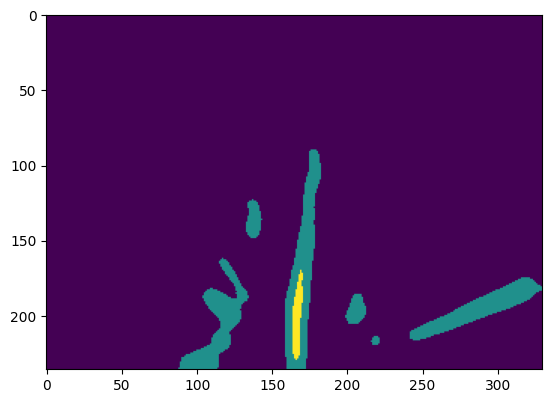

In [3]:

@dataclass
class BEVGrid:
    """Defines the bird's‑eye grid in world meters."""
    meters_per_pixel: float = 0.05
    forward_range_m: tuple[float, float] = (0.0, 30.0)   # (y_min, y_max) forward
    lateral_range_m: tuple[float, float] = (-5.0, 5.0)   # (x_min, x_max) left/right

    @property
    def size(self) -> tuple[int, int]:
        """(W_out, H_out) in pixels for cv2.warpPerspective"""
        x_min, x_max = self.lateral_range_m
        y_min, y_max = self.forward_range_m
        W_out = int(np.round((x_max - x_min) / self.meters_per_pixel))
        H_out = int(np.round((y_max - y_min) / self.meters_per_pixel))
        return (W_out, H_out)

    def scaling_matrix(self) -> np.ndarray:
        """
        S maps destination pixel coords (u,v,1)^T to ground meters (x,y,1)^T.
        y grows forward; we place y forward downward in the BEV image so rows increase with distance.
        """
        x_min, _x_max = self.lateral_range_m
        _y_min, y_max = self.forward_range_m
        mpp = self.meters_per_pixel
        S = np.array([[ mpp,  0.0, x_min],
                      [ 0.0, -mpp, y_max],
                      [ 0.0,  0.0, 1.0 ]], dtype=np.float64)
        return S

class BEVProjector:
    """
    Bird's‑eye view projector.

    Supports:
      1) Calibrated plane homography (ground z=0) using intrinsics + pose.
      2) Trapezoid→rectangle homography (no calibration).

    Conventions:
      World: X right, Y forward, Z up.
      Camera (OpenCV): x right, y down, z forward.
      roll/pitch/yaw are applied as world->camera, ZYX order (yaw, pitch, roll).
    """

    def __init__(self, K: np.ndarray | None = None):
        self.K = None if K is None else self._validate_K(K)
        self.roll = 0.0
        self.pitch = 0.0
        self.yaw = 0.0
        self.height_m = 1.0
        self._H_pg = None  # ground->image homography (if calibrated set)

    # ---------- Public API ----------

    def set_intrinsics(self, K: np.ndarray) -> "BEVProjector":
        self.K = self._validate_K(K)
        self._H_pg = None
        return self

    def set_pose(self, height_m: float, roll: float = 0.0, pitch: float = 0.0, yaw: float = 0.0) -> "BEVProjector":
        self.height_m = float(height_m)
        self.roll = float(roll)
        self.pitch = float(pitch)
        self.yaw = float(yaw)
        self._H_pg = None
        return self

    def warp_calibrated(self, mask01: np.ndarray, grid: BEVGrid) -> np.ndarray:
        """
        Warp a binary mask (1/0, bool or uint8) to BEV using calibration.
        Returns uint8 0/255 mask of shape (H_out, W_out).
        """
        assert self.K is not None, "Call set_intrinsics(K) first."
        H_pg = self._ground_to_image_homography()  # 3x3
        self.H_pg = H_pg
        
        S = grid.scaling_matrix()
        self.S = S
        

        # We need M such that dst <- src: p_dst = S^{-1} * H_pg^{-1} * p_img
        M = np.linalg.inv(S) @ np.linalg.inv(H_pg)
        self.M = M

        
        src = self._to_uint8_255(mask01)
        W_out, H_out = grid.size
        
        bev = cv2.warpPerspective(
            src, M, (W_out, H_out),
            flags=cv2.INTER_NEAREST,
            borderMode=cv2.BORDER_CONSTANT, borderValue=0
        )
        
        return bev

    def warp_trapezoid(self, mask01: np.ndarray, src_quad: np.ndarray, out_size: tuple[int, int]) -> np.ndarray:
        """
        Warp a perspective trapezoid to a rectangle (no calibration needed).
        src_quad: 4x2 float32 in order [TL, TR, BR, BL]
        out_size: (W_out, H_out)
        """
        src = self._to_uint8_255(mask01)
        W_out, H_out = out_size
        dst_quad = np.array([[0, 0],
                             [W_out - 1, 0],
                             [W_out - 1, H_out - 1],
                             [0, H_out - 1]], dtype=np.float32)
        M = cv2.getPerspectiveTransform(src_quad.astype(np.float32), dst_quad)
        bev = cv2.warpPerspective(
            src, M, (W_out, H_out),
            flags=cv2.INTER_NEAREST,
            borderMode=cv2.BORDER_CONSTANT, borderValue=0
        )
        return bev

    def get_calibrated_homography(self, grid: BEVGrid) -> np.ndarray:
        """
        Returns the overall SRC->DST warp matrix M for calibrated BEV:
            p_dst = M * p_img
        so you can reuse it for many frames.
        """
        assert self.K is not None, "Call set_intrinsics(K) first."
        H_pg = self._ground_to_image_homography()
        S = grid.scaling_matrix()
        M = np.linalg.inv(S) @ np.linalg.inv(H_pg)
        return M

    # ---------- Internals ----------

    @staticmethod
    def _validate_K(K: np.ndarray) -> np.ndarray:
        K = np.asarray(K, dtype=np.float64)
        if K.shape != (3, 3) or not np.isfinite(K).all():
            raise ValueError("K must be 3x3 finite matrix")
        return K

    @staticmethod
    def _rot_from_rpy(roll: float, pitch: float, yaw: float) -> np.ndarray:
        """
        World:  X right, Y forward, Z up
        Camera: x right, y down,   z forward (OpenCV)
        Rotate in WORLD (yaw->pitch->roll), then align world->camera.
        """
        # Base alignment: Xw->xc, Yw->zc, Zw->-yc
        R_align = np.array([
            [1.0, 0.0,  0.0],  # Xw -> +xc
            [0.0, 0.0, -1.0],  # Zw -> -yc
            [0.0, 1.0,  0.0],  # Yw -> +zc
        ], dtype=np.float64)
    
        cz, sz = np.cos(yaw),   np.sin(yaw)
        cy, sy = np.cos(pitch), np.sin(pitch)
        cx, sx = np.cos(roll),  np.sin(roll)
    
        Rz = np.array([[ cz, -sz, 0],
                       [ sz,  cz, 0],
                       [  0,   0, 1]], dtype=np.float64)
        Ry = np.array([[ cy, 0, sy],
                       [  0, 1,  0],
                       [-sy, 0, cy]], dtype=np.float64)
        Rx = np.array([[1,  0,   0],
                       [0, cx, -sx],
                       [0, sx,  cx]], dtype=np.float64)
    
        R_world = Rx @ Ry @ Rz          # world -> rotated-world
        return R_align @ R_world        # world -> camera

    def _ground_to_image_homography(self) -> np.ndarray:
        """
        Builds H_pg such that p_img ~ H_pg * p_ground (z=0 plane).
        H_pg = K [r1 r2 t], where t = -R*C and C=(0,0,h)^T (camera center in world).
        """
        if self._H_pg is not None:
            return self._H_pg

        R_wc = self._rot_from_rpy(self.roll, self.pitch, self.yaw)  # world->camera
        t_wc = np.array([[0.0], [0.0], [self.height_m]], dtype=np.float64)  # camera at (0,0,h) in world

        r1 = R_wc[:, 0:1]
        r2 = R_wc[:, 1:2]
        t = R_wc @ (-t_wc)  # -R*C
        H_pg = self.K @ np.hstack([r1, r2, t])
        self._H_pg = H_pg
        return H_pg

    @staticmethod
    def _to_uint8_255(mask01: np.ndarray) -> np.ndarray:
        """Ensure input is uint8 in {0,255} for nearest-neighbor warps."""
        if mask01.dtype != np.uint8:
            src = (mask01.astype(np.uint8) * 255)
        else:
            src = mask01.copy()
            if src.max() == 1:
                src *= 255
        return src






def _build_intrinsics(W, H, K0=None, K0_size=None, fx=1100.0, fy=None):
    if K0 is not None and K0_size is not None:
        W0, H0 = K0_size
        sx, sy = W / float(W0), H / float(H0)
        return np.array([
            [K0[0,0]*sx, 0.0,           K0[0,2]*sx],
            [0.0,        K0[1,1]*sy,    K0[1,2]*sy],
            [0.0,        0.0,           1.0]
        ], dtype=np.float64)
    
    if fy is None:
        fy = fx
    cx, cy = W / 2.0, H / 2.0
    return np.array([
        [fx, 0.0, cx],
        [0.0, fy, cy],
        [0.0, 0.0, 1.0]
    ], dtype=np.float64)

def video_to_bev_tensor(
    video_tensor,
    segmented_video,
    n_frames=None,
    *,
    height_m=1.4,
    pitch_deg_down=6.0,
    roll_deg=0.0,
    yaw_deg=0.0,
    K0=None,
    K0_size=None,
    fx=1100.0,
    fy=None,
    meters_per_pixel=0.10,
    forward_range=(0.5, 40.0),
    lateral_range=(-8.0, 8.0),
    debug=False
):
    N_all = min(len(video_tensor), len(segmented_video))
    N = N_all if n_frames is None else min(n_frames, N_all)

    H, W = segmented_video[0].shape[:2]
    K = _build_intrinsics(W, H, K0=K0, K0_size=K0_size, fx=fx, fy=fy)

    roll = np.deg2rad(roll_deg)
    pitch = -np.deg2rad(pitch_deg_down)
    yaw = np.deg2rad(yaw_deg)

    projector = BEVProjector().set_intrinsics(K).set_pose(
        height_m=height_m,
        roll=roll,
        pitch=pitch,
        yaw=yaw
    )

    grid = BEVGrid(
        meters_per_pixel=meters_per_pixel,
        forward_range_m=forward_range,
        lateral_range_m=lateral_range
    )

    W_out, H_out = grid.size
    bev_tensor = np.zeros((H_out, W_out, N), dtype=np.uint8)

    for i in range(N):
        mask01 = (segmented_video[i] == 0).astype(np.uint8)
        bev = projector.warp_calibrated(mask01=mask01, grid=grid)
        bev_tensor[:, :, i] = bev

        if debug and (i == 0 or (i + 1) == N):
            H_pg, S = projector.H_pg, grid.scaling_matrix()
            A = H_pg @ S
            dst = np.array([[0,0,1],[W_out-1,0,1],[W_out-1,H_out-1,1],[0,H_out-1,1]], dtype=np.float64).T
            img_corners = (A @ dst); img_corners = (img_corners[:2]/img_corners[2]).T
            print(f"[DEBUG frame {i}] BEV corners -> image:\n", img_corners)
            print(f"[DEBUG frame {i}] bev.sum() = {bev.sum()}")

    return bev_tensor, projector, grid


def npy_to_bev_tensor(
    path,
    n_frames=None,
    *,
    pitch_deg_down=6.0,
    height_m=1.4,
    fx=1100.0,
    fy=530,
    meters_per_pixel=0.10,
    forward_range=(0.5, 40.0),
    lateral_range=(-8.0, 8.0),
    debug=False
):
    """
    Convenience wrapper:
    Loads `.npy` path with segmented labels (cam1_*.npy),
    assumes road label is 0,
    and returns BEV-projected tensor.
    """
    assert os.path.exists(path), f"File not found: {path}"
    segmented_video = np.load(path)

    # Dummy grayscale frames for compatibility (same shape, unused)
    H, W = segmented_video[0].shape
    dummy_video = np.stack([
        np.zeros((H, W, 3), dtype=np.uint8)
        for _ in range(len(segmented_video))
    ])

    return video_to_bev_tensor(
        video_tensor=dummy_video,
        segmented_video=segmented_video,
        n_frames=n_frames,
        height_m=height_m,
        pitch_deg_down=pitch_deg_down,
        fx=fx,
        fy=fy,
        meters_per_pixel=meters_per_pixel,
        forward_range=forward_range,
        lateral_range=lateral_range,
        debug=debug
    )


# Process directly from file path:





def rotate_shift_sum(img1, img2, angle_deg=10.0, hor_shift_px=10):
    """
    Rotate img1 by +angle and shift LEFT, rotate img2 by -angle and shift RIGHT.
    Sum the two results on the smallest canvas that fits both, using 0-padding.

    Returns:
        output: np.ndarray of dtype float32 or uint8 (based on input),
                shape (H_out, W_out, C) or (H_out, W_out)
    """
    assert img1.shape == img2.shape, "Both images must be same size"
    H, W = img1.shape[:2]
    is_color = img1.ndim == 3
    C = img1.shape[2] if is_color else 1

    # Convert to float32 for accumulation
    img1_f = img1.astype(np.float32)
    img2_f = img2.astype(np.float32)

    # Rotation matrices around center
    center = (W / 2.0, H / 2.0)
    M1 = cv2.getRotationMatrix2D(center, +angle_deg, 1.0)
    M2 = cv2.getRotationMatrix2D(center, -angle_deg, 1.0)

    # Horizontal shift: img1 left, img2 right
    M1[0, 2] -= hor_shift_px
    M2[0, 2] += hor_shift_px

    # Compute canvas size
    def transform_corners(M):
        corners = np.array([[0,0],[W,0],[W,H],[0,H]], dtype=np.float32)
        ones = np.ones((4,1), dtype=np.float32)
        corners_h = np.hstack([corners, ones])
        transformed = (M @ corners_h.T).T
        return transformed

    corners1 = transform_corners(M1)
    corners2 = transform_corners(M2)
    all_corners = np.vstack([corners1, corners2])

    min_xy = np.floor(all_corners.min(axis=0)).astype(int)
    max_xy = np.ceil(all_corners.max(axis=0)).astype(int)
    out_W, out_H = (max_xy - min_xy)[0], (max_xy - min_xy)[1]

    shift_x, shift_y = -min_xy[0], -min_xy[1]
    M1[:, 2] += shift_x
    M2[:, 2] += shift_x
    M1[1, 2] += shift_y
    M2[1, 2] += shift_y

    # Warp both images
    dsize = (out_W, out_H)
    border_val = 0 if not is_color else (0,) * C
    warp1 = cv2.warpAffine(img1_f, M1, dsize, flags=cv2.INTER_LINEAR, borderValue=border_val)
    warp2 = cv2.warpAffine(img2_f, M2, dsize, flags=cv2.INTER_LINEAR, borderValue=border_val)

    # Sum the results
    summed = warp1 + warp2

    # Return in same dtype as input (clip if needed)
    if np.issubdtype(img1.dtype, np.integer):
        summed = np.clip(summed, 0, 255).astype(img1.dtype)
    return summed




def list_to_numpy_tensor(frames, axis=-1, dtype=None):
    """
    Convert a list of NumPy 2D arrays into a single 3D array (a 'tensor').
    axis=-1  -> shape (H, W, N)   # channels-last style
    axis=0   -> shape (N, H, W)   # batch-first style
    """
    if not frames:
        raise ValueError("frames list is empty")

    base_shape = frames[0].shape
    for i, f in enumerate(frames):
        if f.shape != base_shape:
            raise ValueError(f"All frames must have the same shape: "
                             f"frame 0 is {base_shape}, frame {i} is {f.shape}")
    if dtype is None:
        dtype = np.result_type(*[np.asarray(f).dtype for f in frames])

    stacked = np.stack([np.asarray(f, dtype=dtype) for f in frames], axis=axis)
    return stacked





current_image_path = "1754410876"

#"/workspace/test_results/cam2_1754590241.npy

path = "/workspace/test_results/cam1_"+current_image_path+".npy"
bev_tensor1, projector1, grid1 = npy_to_bev_tensor(
    path, 
    n_frames=300, 
    debug=True,     
    pitch_deg_down=0.0,
    height_m=1,
    fx=300,
    fy=int(530/380*200),
    meters_per_pixel=0.20,
    forward_range=(0.5, 30.0),
    lateral_range=(-20.0, 20.0),
)
path = "/workspace/test_results/cam2_"+current_image_path+".npy"
bev_tensor2, projector2, grid2 = npy_to_bev_tensor(
    path, 
    n_frames=300, 
    debug=True,     
    pitch_deg_down=0.0,
    height_m=1,
    fx=380.0,
    fy=530,
    meters_per_pixel=0.20,
    forward_range=(0.5, 30.0),
    lateral_range=(-20.0, 20.0),
)
bev_cal_tensor = 0
# Shape: (H_bev, W_bev, N)
fps = 12  # Set your desired frame rate
N = 300  # Number of frames

# Generate one combined frame to determine size
# Create the video writer

# Write each frame
combined_list = []
for i in range(N):
    combined = rotate_shift_sum(np.int8(bev_tensor2[:, :, i] / 255), np.int8(bev_tensor1[:, :, i] / 255), angle_deg = -35, hor_shift_px=-40)
    combined_list.append(combined)


tensor_hwn = list_to_numpy_tensor(combined_list, axis=-1, dtype=np.uint8)
import numpy as np
import cv2

def dilate_erode_blur_slice(
    image: np.ndarray, 
    kernel_size: int = 5,     
    blur_ksize: int = 7,
    blur_sigma: float = 1.0
    ) -> np.ndarray:
    """
    Performs dilation followed by erosion (closing) on the slice tensor_hwn[:, :, 50].

    Parameters:
        tensor_hwn (np.ndarray): Input tensor of shape (H, W, N)
        kernel_size (int): Size of the square kernel (default: 5)

    Returns:
        np.ndarray: Closed (dilated + eroded) version of slice [:, :, 50]
    """

    img = image.astype(np.uint8)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (kernel_size, kernel_size))

    
    closed = cv2.erode(img, kernel)
    dilated = cv2.dilate(closed, kernel)

    
    blurred = cv2.GaussianBlur(dilated, (blur_ksize, blur_ksize), blur_sigma)

    

    return blurred

denoised = dilate_erode_blur_slice(tensor_hwn, kernel_size=4, blur_sigma=6, blur_ksize=11)
#help()
plt.imshow(dilate_erode_blur_slice(tensor_hwn, kernel_size=4, blur_sigma=6, blur_ksize=11)[:, :, 10])


In [13]:
import numpy as np
import cv2
from typing import Optional, Tuple
from dataclasses import dataclass

@dataclass
class BEVGrid:
    """Defines the bird's‑eye grid in world meters."""
    meters_per_pixel: float = 0.05
    forward_range_m: tuple[float, float] = (0.0, 30.0)   # (y_min, y_max) forward
    lateral_range_m: tuple[float, float] = (-5.0, 5.0)   # (x_min, x_max) left/right

    @property
    def size(self) -> tuple[int, int]:
        """(W_out, H_out) in pixels for cv2.warpPerspective"""
        x_min, x_max = self.lateral_range_m
        y_min, y_max = self.forward_range_m
        W_out = int(np.round((x_max - x_min) / self.meters_per_pixel))
        H_out = int(np.round((y_max - y_min) / self.meters_per_pixel))
        return (W_out, H_out)

    def scaling_matrix(self) -> np.ndarray:
        """
        S maps destination pixel coords (u,v,1)^T to ground meters (x,y,1)^T.
        y grows forward; we place y forward downward in the BEV image so rows increase with distance.
        """
        x_min, _x_max = self.lateral_range_m
        _y_min, y_max = self.forward_range_m
        mpp = self.meters_per_pixel
        S = np.array([[ mpp,  0.0, x_min],
                      [ 0.0, -mpp, y_max],
                      [ 0.0,  0.0, 1.0 ]], dtype=np.float64)
        return S

class BEVProjector:
    """
    Bird's‑eye view projector.

    Supports:
      1) Calibrated plane homography (ground z=0) using intrinsics + pose.
      2) Trapezoid→rectangle homography (no calibration).

    Conventions:
      World: X right, Y forward, Z up.
      Camera (OpenCV): x right, y down, z forward.
      roll/pitch/yaw are applied as world->camera, ZYX order (yaw, pitch, roll).
    """

    def __init__(self, K: np.ndarray | None = None):
        self.K = None if K is None else self._validate_K(K)
        self.roll = 0.0
        self.pitch = 0.0
        self.yaw = 0.0
        self.height_m = 1.0
        self._H_pg = None  # ground->image homography (if calibrated set)

    # ---------- Public API ----------

    def set_intrinsics(self, K: np.ndarray) -> "BEVProjector":
        self.K = self._validate_K(K)
        self._H_pg = None
        return self

    def set_pose(self, height_m: float, roll: float = 0.0, pitch: float = 0.0, yaw: float = 0.0) -> "BEVProjector":
        self.height_m = float(height_m)
        self.roll = float(roll)
        self.pitch = float(pitch)
        self.yaw = float(yaw)
        self._H_pg = None
        return self

    def warp_calibrated(self, mask01: np.ndarray, grid: BEVGrid) -> np.ndarray:
        """
        Warp a binary mask (1/0, bool or uint8) to BEV using calibration.
        Returns uint8 0/255 mask of shape (H_out, W_out).
        """
        assert self.K is not None, "Call set_intrinsics(K) first."
        H_pg = self._ground_to_image_homography()  # 3x3
        self.H_pg = H_pg
        
        S = grid.scaling_matrix()
        self.S = S
        

        # We need M such that dst <- src: p_dst = S^{-1} * H_pg^{-1} * p_img
        M = np.linalg.inv(S) @ np.linalg.inv(H_pg)
        self.M = M

        
        src = self._to_uint8_255(mask01)
        W_out, H_out = grid.size
        
        bev = cv2.warpPerspective(
            src, M, (W_out, H_out),
            flags=cv2.INTER_NEAREST,
            borderMode=cv2.BORDER_CONSTANT, borderValue=0
        )
        
        return bev

    def warp_trapezoid(self, mask01: np.ndarray, src_quad: np.ndarray, out_size: tuple[int, int]) -> np.ndarray:
        """
        Warp a perspective trapezoid to a rectangle (no calibration needed).
        src_quad: 4x2 float32 in order [TL, TR, BR, BL]
        out_size: (W_out, H_out)
        """
        src = self._to_uint8_255(mask01)
        W_out, H_out = out_size
        dst_quad = np.array([[0, 0],
                             [W_out - 1, 0],
                             [W_out - 1, H_out - 1],
                             [0, H_out - 1]], dtype=np.float32)
        M = cv2.getPerspectiveTransform(src_quad.astype(np.float32), dst_quad)
        bev = cv2.warpPerspective(
            src, M, (W_out, H_out),
            flags=cv2.INTER_NEAREST,
            borderMode=cv2.BORDER_CONSTANT, borderValue=0
        )
        return bev

    def get_calibrated_homography(self, grid: BEVGrid) -> np.ndarray:
        """
        Returns the overall SRC->DST warp matrix M for calibrated BEV:
            p_dst = M * p_img
        so you can reuse it for many frames.
        """
        assert self.K is not None, "Call set_intrinsics(K) first."
        H_pg = self._ground_to_image_homography()
        S = grid.scaling_matrix()
        M = np.linalg.inv(S) @ np.linalg.inv(H_pg)
        return M

    # ---------- Internals ----------

    @staticmethod
    def _validate_K(K: np.ndarray) -> np.ndarray:
        K = np.asarray(K, dtype=np.float64)
        if K.shape != (3, 3) or not np.isfinite(K).all():
            raise ValueError("K must be 3x3 finite matrix")
        return K

    @staticmethod
    def _rot_from_rpy(roll: float, pitch: float, yaw: float) -> np.ndarray:
        """
        World:  X right, Y forward, Z up
        Camera: x right, y down,   z forward (OpenCV)
        Rotate in WORLD (yaw->pitch->roll), then align world->camera.
        """
        # Base alignment: Xw->xc, Yw->zc, Zw->-yc
        R_align = np.array([
            [1.0, 0.0,  0.0],  # Xw -> +xc
            [0.0, 0.0, -1.0],  # Zw -> -yc
            [0.0, 1.0,  0.0],  # Yw -> +zc
        ], dtype=np.float64)
    
        cz, sz = np.cos(yaw),   np.sin(yaw)
        cy, sy = np.cos(pitch), np.sin(pitch)
        cx, sx = np.cos(roll),  np.sin(roll)
    
        Rz = np.array([[ cz, -sz, 0],
                       [ sz,  cz, 0],
                       [  0,   0, 1]], dtype=np.float64)
        Ry = np.array([[ cy, 0, sy],
                       [  0, 1,  0],
                       [-sy, 0, cy]], dtype=np.float64)
        Rx = np.array([[1,  0,   0],
                       [0, cx, -sx],
                       [0, sx,  cx]], dtype=np.float64)
    
        R_world = Rx @ Ry @ Rz          # world -> rotated-world
        return R_align @ R_world        # world -> camera

    def _ground_to_image_homography(self) -> np.ndarray:
        """
        Builds H_pg such that p_img ~ H_pg * p_ground (z=0 plane).
        H_pg = K [r1 r2 t], where t = -R*C and C=(0,0,h)^T (camera center in world).
        """
        if self._H_pg is not None:
            return self._H_pg

        R_wc = self._rot_from_rpy(self.roll, self.pitch, self.yaw)  # world->camera
        t_wc = np.array([[0.0], [0.0], [self.height_m]], dtype=np.float64)  # camera at (0,0,h) in world

        r1 = R_wc[:, 0:1]
        r2 = R_wc[:, 1:2]
        t = R_wc @ (-t_wc)  # -R*C
        H_pg = self.K @ np.hstack([r1, r2, t])
        self._H_pg = H_pg
        return H_pg

    @staticmethod
    def _to_uint8_255(mask01: np.ndarray) -> np.ndarray:
        """Ensure input is uint8 in {0,255} for nearest-neighbor warps."""
        if mask01.dtype != np.uint8:
            src = (mask01.astype(np.uint8) * 255)
        else:
            src = mask01.copy()
            if src.max() == 1:
                src *= 255
        return src







def make_projector_and_grid(
    frame_shape: Tuple[int, int],          # (H, W) of your input npy frame
    *,
    fx: float = 1100.0,
    fy: Optional[float] = None,
    roll_deg: float = 0.0,
    pitch_deg_down: float = 6.0,
    yaw_deg: float = 0.0,
    height_m: float = 1.4,
    meters_per_pixel: float = 0.10,
    forward_range: Tuple[float, float] = (0.5, 40.0),
    lateral_range: Tuple[float, float] = (-8.0, 8.0),
) -> tuple:
    """Build and return (projector, grid) once, then reuse them for all frames."""
    H, W = frame_shape
    fy_loc = fx if fy is None else fy
    K = np.array([[fx,    0.0,  W / 2.0],
                  [0.0,  fy_loc, H / 2.0],
                  [0.0,   0.0,   1.0   ]], dtype=np.float64)

    roll  = np.deg2rad(roll_deg)
    pitch = -np.deg2rad(pitch_deg_down)   # down is negative in this convention
    yaw   = np.deg2rad(yaw_deg)

    projector = BEVProjector().set_intrinsics(K).set_pose(
        height_m=height_m, roll=roll, pitch=pitch, yaw=yaw
    )
    grid = BEVGrid(
        meters_per_pixel=meters_per_pixel,
        forward_range_m=forward_range,
        lateral_range_m=lateral_range
    )
    return projector, grid


def npy_frame_to_bev(
    seg_frame: np.ndarray,                 # (H, W) labels or binary
    projector: "BEVProjector",
    grid: "BEVGrid",
    *,
    road_label: int = 0
) -> np.ndarray:
    """
    Use your BEVProjector/BEVGrid to warp a single npy frame to BEV.
    Returns uint8 BEV mask (H_out, W_out) with values {0,255}.
    """
    # Build 1/0 mask (road=1). If already binary uint8, just threshold.
    if seg_frame.dtype == np.uint8 and seg_frame.max() in (1, 255):
        mask01 = (seg_frame > 0).astype(np.uint8)
    else:
        mask01 = (seg_frame == road_label).astype(np.uint8)

    bev = projector.warp_calibrated(mask01=mask01, grid=grid)  # returns uint8 {0,255}
    return bev


seg = np.load('/workspace/test_results/cam2_1754410876.npy')[100]
projector, grid = make_projector_and_grid(
    frame_shape=seg.shape,
    fx=380.0, fy=530.0,
    height_m=1.0,
    pitch_deg_down=0.0,
    meters_per_pixel=0.20,
    forward_range=(0.5, 30.0),
    lateral_range=(-20.0, 20.0),
)

bev = npy_frame_to_bev(seg, projector, grid, road_label=0)
# bev is (H_out, W_out) uint8 {0,255}



In [11]:
left_camera = np.load('/workspace/test_results/cam1_1754410876.npy')
right_camera = np.load('/workspace/test_results/cam2_1754410876.npy')


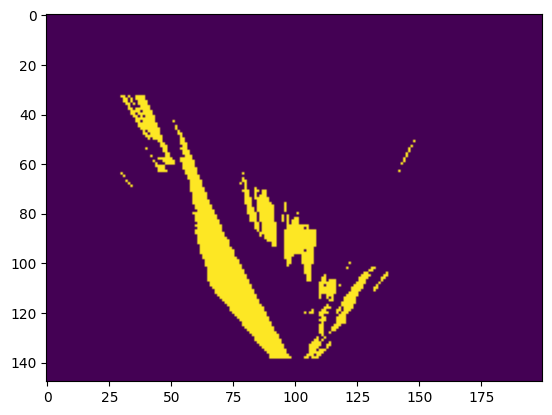

In [10]:
import matplotlib.pyplot as plt
plt.imshow(bev)

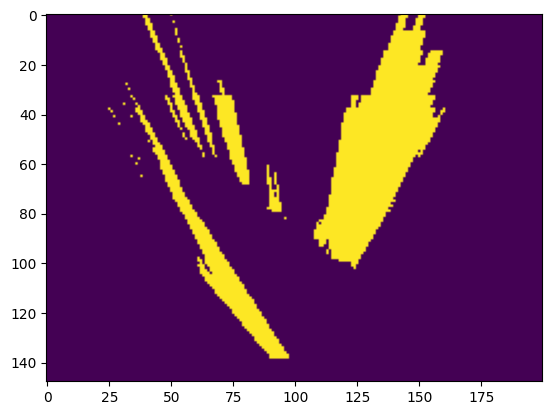

In [10]:
plt.imshow(bev_tensor2[:, :, 200])

In [221]:
t2v(denoised, "gray.mp4", fps=15, normalize=True)


In [439]:
flower_tensor_road = make_rotating_rect_tensor(H=236, W=330, n= 100, length=130, thickness=5)
flower_tensor_collision = make_rotating_rect_tensor(H=236, W=330, n= 100, length=60, thickness=5)

In [103]:
H, W, M = flower_tensor.shape

D = denoised[:, :, 40].astype(np.int64)       # or float64 / bool
F = flower_tensor.astype(np.int64)

# Method A: dot
dot_total = np.dot(D.reshape(1, -1), F.reshape(-1, M)).sum()

# Method B: broadcasted multiply
mul_total = (D[:, :, None] * F).sum()

print(dot_total, mul_total)  # should be equal now


70130 70130


In [101]:
(np.dot(denoised[:, :, 40].reshape(-1, 1).T, flower_tensor[:, :, :].reshape(-1, 250)).T).sum()

31986

In [124]:
# denoised: (H, W, N)
# flower_tensor: (H, W, M)
import time

time0 = time.time()
overlap_NM = np.sum(
    np.multiply(
        denoised[:, :, :, None],      # (H, W, N, 1)
        flower_tensor[:, :, None, :]  # (H, W, 1, M)
    ),
    axis=(0, 1)
)  # shape: (N, M)
print(time.time() - time0)

1.9135160446166992


In [722]:
import numpy as np

import numpy as np
import cv2

lista_ = []
lista__ = []
lista = []


def compute_overlap_per_frame_blurred(denoised: np.ndarray, 
        flower_tensor_road: np.ndarray, 
        flower_tensor_colision: np.ndarray, 
        collision_threshold: int = 180,
        ksize: int = 5, 
        sigma: float = 0,    
        top_percent: float = 5.0,      # e.g. 5 -> top 5% pixels
        top_threshold: float = 0.0,
        remembrance: float = 0,
        centre_bias_coefficient = 0.6
        ) -> np.ndarray:
    """
    Compute overlap between blurred `denoised` frames and all flower masks using np.multiply.
    
    Args:
        denoised: (H, W, N)
        flower_tensor: (H, W, M)
        ksize: kernel size for Gaussian blur (must be odd)
        sigma: standard deviation of the Gaussian kernel (0 = auto)

    Returns:
        overlap_NM: (N, M)
    """
    H, W, N = denoised.shape
    _, _, M = flower_tensor_road.shape

    overlap_NM = np.zeros((N, M), dtype=np.int32)
    list_of_chosen_roads = []
    centre_bias_array = decreasing_positive_quadratic(n=flower_tensor_road.shape[2], k = centre_bias_coefficient)

    sel_last = np.zeros((flower_tensor_road.shape[2], 1))

    for i in range(N):
        frame = denoised[:, :, i].astype(np.float32)


        convolved = np.sum(np.multiply(frame[:, :, None], flower_tensor_road), axis=(0, 1))
        # Apply Gaussian blur to the frame
        convolved_biased = np.multiply(convolved, centre_bias_array)
        lista.append(convolved_biased)

        blurred = gaussian_filter1d(convolved_biased, sigma=sigma).reshape(-1, 1)

        
        residual = (gaussian_filter1d(np.float32(sel_last)[:, 0], sigma=16) * remembrance).reshape(-1, 1)

        
        convolved_biased_ = np.multiply(blurred, (1 + residual)) 

        lista__.append(residual)
        #lista__.append(sel_last)

        
        lista_.append(convolved_biased_)
        


        cutoff = np.percentile(convolved_biased_, 100.0 - top_percent)
        
        
        sel = (convolved_biased_ >= cutoff) & (convolved_biased_ >= top_threshold)

        max_indicy = np.max(gaussian_filter1d(np.float16(sel[])))
        break

        sel_indices = np.where(sel[:, 0])[0] 


    


        

        reduced_flower_tensor_colision = flower_tensor_colision[:, :, sel[:, 0]]
        

        
        convolved_colision = np.sum(np.multiply(frame[:, :, None], reduced_flower_tensor_colision), axis=(0, 1))  
        
        valid_mask = convolved_colision >= collision_threshold
        valid_indices = sel_indices[valid_mask]



        selected_sum = flower_tensor_road[:, :, valid_indices].sum(axis=2) 
        
        list_of_chosen_roads.append(selected_sum)


        # Multiply blurred frame with all masks, then sum over H and W
        overlap_NM[i] = blurred[:, 0]

        sel_new = np.zeros_like(sel[:, 0], dtype=bool)
        sel_new[valid_indices] = True
        sel = sel_new[:, None]  
        sel_last = sel

        
    return overlap_NM, list_of_chosen_roads


import time

time0 = time.time()
overlap, roads = compute_overlap_per_frame_blurred(denoised, flower_tensor_road, flower_tensor_collision, ksize=5, sigma=4, top_percent=3, top_threshold=700, remembrance=8)
print("Elapsed:", time.time() - time0)

roads_tensor = list_to_numpy_tensor(roads)


t2v(roads_tensor, "roads" + current_image_path + str(time.time()) + ".mp4", fps=15)

SyntaxError: invalid syntax. Perhaps you forgot a comma? (3565685981.py, line 73)

<module 'numpy' from '/usr/local/lib/python3.10/dist-packages/numpy/__init__.py'>

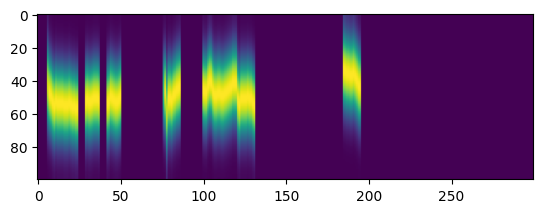

In [602]:
plt.imshow(list_to_numpy_tensor(lista__)[:, 0, :])


In [792]:
plt.plot(lista_[50])

IndexError: list index out of range

In [962]:
def compute_best_road_and_collision_viz(
    denoised: np.ndarray,                  # (H, W, N)
    flower_tensor_road: np.ndarray,        # (H, W, M_road)
    flower_tensor_collision: np.ndarray,   # (H, W, M_small)
    *,
    collision_threshold: int = 180,
    centre_bias_coefficient: float = 0.6,
    sigma_scores: float = 4.0,
    remembrance: float = 0.0,
    residual_sigma: float = 16.0,
    small_neighbour_sigma: float = 2.0,
    small_top_k: int = 1,
    road_color=(0, 255, 0),
    small_color=(0, 0, 255),
    convergent_with_road = 5,
    # thresholds:
    road_min_abs: float = 0.0,
    road_min_frac_of_max: float = 0.0,
    collision_min_abs: float = 0.0,
    collision_min_frac_of_max: float = 0.0,
    # NEW: highlight color for the single selected road
    selected_road_color=(0, 255, 255)
):
    """
    Returns:
        viz_tensor: (H, W, 3, N) uint8 visualization
        best_road_indices: (N,) int array of best road indices
        best_small_indices_per_frame: list of 1D arrays of small indices (length N)
    """
    H, W, N = denoised.shape
    _, _, M_road = flower_tensor_road.shape
    _, _, M_small = flower_tensor_collision.shape

    centre_bias_array = decreasing_positive_quadratic(n=M_road, k=centre_bias_coefficient).astype(np.float32)
    if centre_bias_array.ndim == 1:
        centre_bias_array = centre_bias_array
    else:
        centre_bias_array = centre_bias_array.reshape(-1)

    sel_last = np.zeros((M_road,), dtype=np.float32)

    viz_tensor = np.zeros((H, W, 3, N), dtype=np.uint8)
    best_road_indices = np.empty((N,), dtype=np.int32)
    best_small_indices_per_frame = []

    # helper: group contiguous angle indices (no wraparound)
    def _group_contiguous(idxs: np.ndarray):
        if idxs.size == 0:
            return []
        idxs = np.sort(idxs)
        groups = []
        start = idxs[0]
        prev = idxs[0]
        for x in idxs[1:]:
            if x == prev + 1:
                prev = x
            else:
                groups.append(np.arange(start, prev + 1))
                start = prev = x
        groups.append(np.arange(start, prev + 1))
        return groups

    for i in range(N):
        frame = denoised[:, :, i].astype(np.float32)

        # ---- ROAD (large tensor) ----
        road_scores = np.sum(frame[:, :, None] * flower_tensor_road.astype(np.float32), axis=(0, 1))
        road_scores *= centre_bias_array
        road_scores = gaussian_filter1d(road_scores, sigma=sigma_scores)

        if remembrance > 0.0:
            residual_smoothed = gaussian_filter1d(sel_last, sigma=residual_sigma)
            road_scores = road_scores * (1.0 + remembrance * residual_smoothed)

        best_road_idx = int(np.argmax(road_scores))
        best_road_indices[i] = best_road_idx

        road_gate = max(road_min_abs, road_min_frac_of_max * (float(road_scores.max()) if road_scores.size else 0.0))
        draw_road = bool(road_scores[best_road_idx] >= road_gate)

        sel_last = np.zeros_like(sel_last)
        sel_last[best_road_idx] = 1.0

        # ---- COLLISION (small tensor) ----
        small_scores = np.sum(frame[:, :, None] * flower_tensor_collision.astype(np.float32), axis=(0, 1))
        small_scores = gaussian_filter1d(small_scores, sigma=sigma_scores)

        bias = (1.0 + (road_scores / ((road_scores.sum() + 1e-8) * convergent_with_road)))
        small_scores_biased = small_scores * bias[:M_small] if bias.shape[0] != M_small else small_scores * bias

        coll_gate = max(
            collision_min_abs,
            collision_min_frac_of_max * (float(small_scores_biased.max()) if small_scores_biased.size else 0.0)
        )
        valid_small = np.where(small_scores_biased >= coll_gate)[0]

        if valid_small.size > 0:
            k = int(max(1, min(small_top_k, valid_small.size)))
            valid_scores = small_scores_biased[valid_small]
            sel = np.argpartition(-valid_scores, kth=k-1)[:k]
            best_small_idxs = valid_small[sel]
            best_small_idxs = best_small_idxs[np.argsort(-small_scores_biased[best_small_idxs])]
        else:
            best_small_idxs = np.array([], dtype=int)

        best_small_indices_per_frame.append(best_small_idxs)

        # ---- Visualization ----
        img = np.zeros((H, W, 3), dtype=np.uint8)

        # Keep ALL roads above threshold, but for each contiguous group keep ONLY the strongest angle,
        # and scale its intensity proportional to the group size (normalized by max group size).
        kept_indices = np.where(road_scores >= road_gate)[0]
        if kept_indices.size > 0:
            groups = _group_contiguous(kept_indices)
            max_len = max(len(g) for g in groups) if groups else 1
            base_col = np.array(road_color, dtype=np.float32)

            for g in groups:
                g = np.array(g, dtype=int)
                # strongest contender within the group
                g_best = g[np.argmax(road_scores[g])]
                best_mask = flower_tensor_road[:, :, g_best].astype(bool)

                # intensity ∝ group size (normalized)
                factor = 0.5 + 0.5 * (len(g) / max_len)  # in [0.5, 1.0]
                col = np.clip(np.round(base_col * factor), 0, 255).astype(np.uint8)

                img[best_mask] = col

        # Selected (global best) road overrides with a distinct color
        if draw_road:
            sel_mask = flower_tensor_road[:, :, best_road_idx].astype(bool)
            img[sel_mask] = selected_road_color

        # Small preferred directions on top (unchanged)
        if best_small_idxs.size > 0:
            if best_small_idxs.size == 1:
                small_mask = flower_tensor_collision[:, :, best_small_idxs[0]].astype(bool)
                img[small_mask] = small_color
            else:
                small_mask_union = np.any(flower_tensor_collision[:, :, best_small_idxs].astype(bool), axis=2)
                img[small_mask_union] = small_color

        viz_tensor[:, :, :, i] = img

    return viz_tensor, best_road_indices, best_small_indices_per_frame

time0 = time.time()

viz_tensor, best_road_indices, best_small_indices_per_frame = compute_best_road_and_collision_viz(
    denoised=denoised,
    flower_tensor_road=flower_tensor_road,
    flower_tensor_collision=flower_tensor_collision,
    centre_bias_coefficient=0.6,
    sigma_scores=4.0,
    remembrance=8,
    residual_sigma=16.0,
    small_neighbour_sigma=2.0,
    small_top_k=1,
    road_color=(100, 100, 0),
    small_color=(0, 0, 255),
    convergent_with_road=5,
    # thresholds:
    road_min_abs=40,
    road_min_frac_of_max=0.10,     # e.g., draw road only if >=10% of max score
    collision_min_abs=300,
    collision_min_frac_of_max=0.30 # e.g., keep small dirs >=30% of max biased score
)

print(time.time() - time0)


6.410734415054321


In [943]:
# Save the RGB video
def help():
    viz_tensor, best_road_indices, best_small_indices_per_frame = compute_best_road_and_collision_viz(
        denoised=denoised,
        flower_tensor_road=flower_tensor_road,
        flower_tensor_collision=flower_tensor_collision,
        centre_bias_coefficient=0.6,
        sigma_scores=4.0,
        remembrance=8,
        residual_sigma=16.0,
        small_neighbour_sigma=2.0,
        small_top_k=1,
        road_color=(100, 100, 0),
        small_color=(0, 0, 255),
        convergent_with_road=5,
        # thresholds:
        road_min_abs=650,
        road_min_frac_of_max=0.10,     # e.g., draw road only if >=10% of max score
        collision_min_abs=300,
        collision_min_frac_of_max=0.30 # e.g., keep small dirs >=30% of max biased score
    )
    t2v(viz_tensor, "viz_" + current_image_path + str(time.time()) + ".mp4", fps=15)


In [961]:
t2v(viz_tensor, "viz_" + current_image_path + str(time.time()) + ".mp4", fps=15)

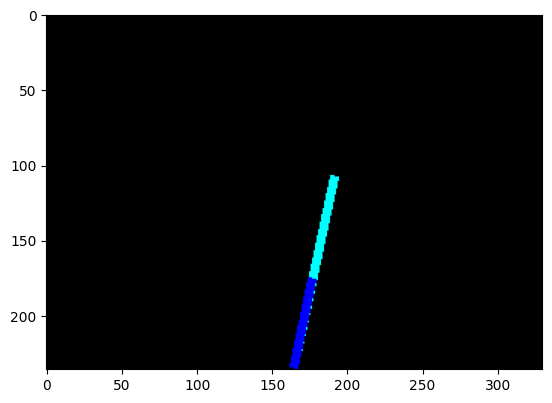

In [960]:
plt.imshow(viz_tensor[:, :, :, n])

In [821]:
import numpy as np
import cv2

def _angle_from_index(idx: int, M: int, start_deg=180.0, end_deg=0.0) -> float:
    # Assumes same angle sweep as make_rotating_rect_tensor: 180° -> 0°
    if M <= 1:
        return (start_deg + end_deg) * 0.5
    step = (end_deg - start_deg) / (M - 1)
    return start_deg + idx * step  # degrees

def _unit_dirs_from_angle_deg(theta_deg: float):
    # Consistent with your generator: dx=cos, dy=-sin (y down)
    th = np.deg2rad(theta_deg)
    dx = np.cos(th)
    dy = -np.sin(th)
    dir_vec = np.array([dx, dy], dtype=np.float32)
    left_n  = np.array([-dy, dx], dtype=np.float32)
    right_n = -left_n
    # normalize just in case
    for v in (dir_vec, left_n, right_n):
        n = np.linalg.norm(v) + 1e-8
        v /= n
    return dir_vec, left_n, right_n

def _rect_mask(H, W, p0, p1, thickness):
    # Filled rectangle defined by centerline p0->p1 and thickness
    p0 = np.asarray(p0, dtype=np.float32)
    p1 = np.asarray(p1, dtype=np.float32)
    v  = p1 - p0
    L  = np.linalg.norm(v) + 1e-8
    t  = thickness / 2.0
    n  = np.array([-v[1], v[0]], dtype=np.float32) / L  # normal unit
    poly = np.stack([
        p0 + n * t, p0 - n * t, p1 - n * t, p1 + n * t
    ]).astype(np.int32)
    mask = np.zeros((H, W), dtype=np.uint8)
    cv2.fillPoly(mask, [poly], 1)
    return mask

def _tiles_present_next_to_road(
    frame_bin: np.ndarray, region_mask: np.ndarray,
    grid_rc=(10,12), per_tile_min_sum=30, min_tiles=2
) -> bool:
    H, W = frame_bin.shape
    R, C = grid_rc
    ys = np.linspace(0, H, R+1, dtype=int)
    xs = np.linspace(0, W, C+1, dtype=int)
    region_frame = (frame_bin & region_mask.astype(bool)).astype(np.uint8)

    cnt = 0
    for gi in range(R):
        for gj in range(C):
            y0, y1 = ys[gi], ys[gi+1]
            x0, x1 = xs[gj], xs[gj+1]
            tile_sum = int(region_frame[y0:y1, x0:x1].sum())
            if tile_sum >= per_tile_min_sum:
                cnt += 1
                if cnt >= min_tiles:
                    return True
    return False

def detect_crossroads_for_frame(
    frame: np.ndarray,                    # (H, W) binary-ish
    best_road_idx: int,
    flower_tensor_road: np.ndarray,       # (H, W, M_road) to infer angle/anchor
    *,
    # grid presence test
    grid_rc=(10,12),
    per_tile_min_sum=30,
    min_tiles_required=2,
    # geometric params
    road_anchor=(None, None),             # defaults to bottom-center if None
    anchor_frac_along_road=0.75,          # where along road the cross-arm starts [0..1]
    side_length_px=90,
    side_thickness_px=14,
    side_angle_jitter_deg=12.0,           # try ± jitter around perfect 90°
    jitter_steps=3,                       # number of jitter samples each side
    # thresholds
    frame_bin_threshold=0.5,              # binarize frame
    side_min_abs=200,                     # min overlap to accept a side
    side_min_frac_of_max=0.25,            # relative to best candidate on that side
    # drawing colors
    left_color=(255, 255, 0),             # BGR yellow
    right_color=(255, 0, 0)               # BGR blue-ish red
):
    H, W, M_road = flower_tensor_road.shape
    I = (frame >= frame_bin_threshold).astype(np.uint8)

    # Angle from best road index
    theta_deg = _angle_from_index(best_road_idx, M_road, start_deg=180.0, end_deg=0.0)
    fwd, left_n, right_n = _unit_dirs_from_angle_deg(theta_deg)

    # Road anchor default: same as your generator (bottom-center)
    if road_anchor[0] is None or road_anchor[1] is None:
        x0, y0 = W // 2, H - 1
    else:
        x0, y0 = road_anchor

    # Estimate road length from the mask’s farthest point in that slice
    road_mask = flower_tensor_road[:, :, best_road_idx].astype(bool)
    ys, xs = np.nonzero(road_mask)
    if len(xs) == 0:
        # no road pixels? early return
        return False, False, np.zeros_like(I), np.zeros_like(I), 0.0, 0.0, np.zeros((H, W, 3), dtype=np.uint8)

    # Approximate far endpoint along forward direction
    # Take median of far band for robustness
    proj = (xs - x0) * fwd[0] + (ys - y0) * fwd[1]
    L_est = float(np.percentile(proj[proj > 0], 90)) if np.any(proj > 0) else 60.0
    p_anchor = np.array([x0, y0], dtype=np.float32) + fwd * (anchor_frac_along_road * L_est)

    # Build thin side "region bands" next to road to test tile presence
    band_len = max(30.0, side_length_px * 0.6)
    band_th  = max(10.0, side_thickness_px * 0.8)

    def band_mask(nvec):
        p1 = p_anchor + nvec * band_len
        return _rect_mask(H, W, p_anchor, p1, band_th)

    left_band  = band_mask(left_n)
    right_band = band_mask(right_n)

    left_tiles_ok  = _tiles_present_next_to_road(I, left_band,  grid_rc, per_tile_min_sum, min_tiles_required)
    right_tiles_ok = _tiles_present_next_to_road(I, right_band, grid_rc, per_tile_min_sum, min_tiles_required)

    # If no tiles present on a side, we skip fitting for that side
    # (per your spec: "if tiles are present next to the selected rectangle (road) try to fit…")
    def fit_side(nvec, do_fit: bool):
        if not do_fit:
            return np.zeros_like(I), 0.0, False
        # Jitter angles around perfect normal
        n_steps = max(1, int(jitter_steps))  # <-- use a local var, no assignment to outer name
        jitters = np.linspace(-side_angle_jitter_deg, side_angle_jitter_deg, n_steps).astype(np.float32)
    
        best_score = -1.0
        best_mask  = None
    
        base_ang = np.rad2deg(np.arctan2(-nvec[1], nvec[0]))  # invert y for consistency
        for a in jitters:
            th = np.deg2rad(base_ang + a)
            n = np.array([np.cos(th), -np.sin(th)], dtype=np.float32)
            p1 = p_anchor + n * side_length_px
            mask = _rect_mask(H, W, p_anchor, p1, side_thickness_px)
            score = float((mask * I).sum())
            if score > best_score:
                best_score = score
                best_mask = mask
    
        # Gate by absolute / fractional thresholds
        frac_gate = side_min_frac_of_max * (best_score if best_score > 0 else 0.0)
        gate = max(side_min_abs, frac_gate)
        ok = best_score >= gate
        return best_mask.astype(np.uint8), best_score, ok

    left_mask,  left_score,  left_ok  = fit_side(left_n,  left_tiles_ok)
    right_mask, right_score, right_ok = fit_side(right_n, right_tiles_ok)

    # Simple overlay for this frame
    img = np.zeros((H, W, 3), dtype=np.uint8)
    if left_ok:
        img[left_mask.astype(bool)] = left_color
    if right_ok:
        img[right_mask.astype(bool)] = right_color

    return left_ok, right_ok, left_mask, right_mask, left_score, right_score, img
import numpy as np
import cv2

def _angle_from_index(idx: int, M: int, start_deg=180.0, end_deg=0.0) -> float:
    if M <= 1:
        return (start_deg + end_deg) * 0.5
    step = (end_deg - start_deg) / (M - 1)
    return start_deg + idx * step  # degrees

def _unit_dirs_from_angle_deg(theta_deg: float):
    th = np.deg2rad(theta_deg)
    dx = np.cos(th); dy = -np.sin(th)
    dir_vec = np.array([dx, dy], dtype=np.float32)
    left_n  = np.array([-dy, dx], dtype=np.float32)
    right_n = -left_n
    for v in (dir_vec, left_n, right_n):
        v /= (np.linalg.norm(v) + 1e-8)
    return dir_vec, left_n, right_n

def _rect_mask(H, W, p0, p1, thickness):
    p0 = np.asarray(p0, dtype=np.float32); p1 = np.asarray(p1, dtype=np.float32)
    v  = p1 - p0; L = np.linalg.norm(v) + 1e-8
    n  = np.array([-v[1], v[0]], dtype=np.float32) / L
    t  = thickness / 2.0
    poly = np.stack([p0 + n*t, p0 - n*t, p1 - n*t, p1 + n*t]).astype(np.int32)
    mask = np.zeros((H, W), dtype=np.uint8)
    cv2.fillPoly(mask, [poly], 1)
    return mask

def _tiles_present_next_to_road(frame_bin: np.ndarray, region_mask: np.ndarray,
                                grid_rc=(10,12), per_tile_min_sum=30, min_tiles=2) -> bool:
    H, W = frame_bin.shape
    R, C = grid_rc
    ys = np.linspace(0, H, R+1, dtype=int)
    xs = np.linspace(0, W, C+1, dtype=int)
    region_frame = (frame_bin & region_mask.astype(bool)).astype(np.uint8)
    cnt = 0
    for gi in range(R):
        for gj in range(C):
            y0, y1 = ys[gi], ys[gi+1]; x0, x1 = xs[gj], xs[gj+1]
            if int(region_frame[y0:y1, x0:x1].sum()) >= per_tile_min_sum:
                cnt += 1
                if cnt >= min_tiles: return True
    return False

def _ang_diff_deg(a_deg: float, b_deg: float) -> float:
    """Smallest absolute difference between two angles in degrees (0..180]."""
    d = (a_deg - b_deg + 180.0) % 360.0 - 180.0
    return abs(d)

def detect_crossroads_for_frame(
    frame: np.ndarray,                    # (H, W) binary-ish
    best_road_idx: int,
    flower_tensor_road: np.ndarray,       # (H, W, M_road)
    *,
    grid_rc=(10,12),
    per_tile_min_sum=30,
    min_tiles_required=2,
    road_anchor=(None, None),
    anchor_frac_along_road=0.75,
    side_length_px=90,
    side_thickness_px=14,
    side_angle_jitter_deg=12.0,
    jitter_steps=3,
    frame_bin_threshold=0.5,
    side_min_abs=200,
    side_min_frac_of_max=0.25,
    left_color=(255, 255, 0),
    right_color=(255, 0, 0),
    # NEW: constraints
    y_min_frac=0.5,                 # only score pixels with y >= H*y_min_frac (bottom half by default)
    perp_tolerance_deg=20.0         # candidate must be within ±tolerance of 90° to the road
):
    H, W, M_road = flower_tensor_road.shape
    I = (frame >= frame_bin_threshold).astype(np.uint8)

    # Bottom-half mask (NEW)
    bottom_mask = np.zeros((H, W), dtype=np.uint8)
    bottom_mask[int(H * y_min_frac):, :] = 1

    # Road direction & normals
    theta_deg = _angle_from_index(best_road_idx, M_road, start_deg=180.0, end_deg=0.0)
    fwd, left_n, right_n = _unit_dirs_from_angle_deg(theta_deg)
    fwd_ang_deg = np.rad2deg(np.arctan2(-fwd[1], fwd[0]))

    # Anchor (default bottom-center)
    if road_anchor[0] is None or road_anchor[1] is None:
        x0, y0 = W // 2, H - 1
    else:
        x0, y0 = road_anchor

    road_mask = flower_tensor_road[:, :, best_road_idx].astype(bool)
    ys, xs = np.nonzero(road_mask)
    if len(xs) == 0:
        return False, False, np.zeros_like(I), np.zeros_like(I), 0.0, 0.0, np.zeros((H, W, 3), dtype=np.uint8)

    proj = (xs - x0) * fwd[0] + (ys - y0) * fwd[1]
    L_est = float(np.percentile(proj[proj > 0], 90)) if np.any(proj > 0) else 60.0
    p_anchor = np.array([x0, y0], dtype=np.float32) + fwd * (anchor_frac_along_road * L_est)

    band_len = max(30.0, side_length_px * 0.6)
    band_th  = max(10.0, side_thickness_px * 0.8)

    def band_mask(nvec):
        p1 = p_anchor + nvec * band_len
        return _rect_mask(H, W, p_anchor, p1, band_th)

    left_band  = band_mask(left_n)
    right_band = band_mask(right_n)

    left_tiles_ok  = _tiles_present_next_to_road(I, left_band,  grid_rc, per_tile_min_sum, min_tiles_required)
    right_tiles_ok = _tiles_present_next_to_road(I, right_band, grid_rc, per_tile_min_sum, min_tiles_required)

    def fit_side(nvec, do_fit: bool):
        if not do_fit:
            return np.zeros_like(I), 0.0, False
        n_steps = max(1, int(jitter_steps))
        jitters = np.linspace(-side_angle_jitter_deg, side_angle_jitter_deg, n_steps).astype(np.float32)

        best_score = -1.0
        best_mask  = None
        best_ang_ok = False

        base_ang = np.rad2deg(np.arctan2(-nvec[1], nvec[0]))  # angle of ideal normal (deg)
        for a in jitters:
            n_ang = base_ang + a
            # NEW: perpendicularity gate (difference from 90° wrt road direction)
            dev_from_perp = abs(90.0 - _ang_diff_deg(n_ang, fwd_ang_deg))
            if dev_from_perp > perp_tolerance_deg:
                continue  # reject angles not sufficiently perpendicular

            th = np.deg2rad(n_ang)
            n = np.array([np.cos(th), -np.sin(th)], dtype=np.float32)
            p1 = p_anchor + n * side_length_px
            mask = _rect_mask(H, W, p_anchor, p1, side_thickness_px)

            # NEW: score only in bottom region
            score = float((mask & bottom_mask & I).sum())

            if score > best_score:
                best_score = score
                best_mask  = mask
                best_ang_ok = True

        if best_mask is None or not best_ang_ok:
            return np.zeros_like(I), 0.0, False

        # Thresholding (unchanged)
        frac_gate = side_min_frac_of_max * (best_score if best_score > 0 else 0.0)
        gate = max(side_min_abs, frac_gate)
        ok = best_score >= gate

        # EXTRA: ensure mask centroid is in bottom half as well (robustness)
        if ok:
            ys_m, xs_m = np.nonzero(best_mask)
            if ys_m.size > 0 and float(ys_m.mean()) < H * y_min_frac:
                ok = False

        return best_mask.astype(np.uint8), best_score, ok

    left_mask,  left_score,  left_ok  = fit_side(left_n,  left_tiles_ok)
    right_mask, right_score, right_ok = fit_side(right_n, right_tiles_ok)

    img = np.zeros((H, W, 3), dtype=np.uint8)
    if left_ok:  img[left_mask.astype(bool)]  = left_color
    if right_ok: img[right_mask.astype(bool)] = right_color

    return left_ok, right_ok, left_mask, right_mask, left_score, right_score, img

def detect_crossroads_over_video(
    denoised: np.ndarray,                 # (H, W, N)
    best_road_indices: np.ndarray,        # (N,)
    flower_tensor_road: np.ndarray,       # (H, W, M_road)
    *,
    grid_rc=(10,12),
    per_tile_min_sum=30,
    min_tiles_required=2,
    anchor_frac_along_road=0.75,
    side_length_px=90,
    side_thickness_px=14,
    side_angle_jitter_deg=12.0,
    jitter_steps=3,
    frame_bin_threshold=0.5,
    side_min_abs=200,
    side_min_frac_of_max=0.25,
    left_color=(255, 255, 0),
    right_color=(255, 0, 0),
    # NEW pass-throughs
    y_min_frac=0.5,
    perp_tolerance_deg=20.0
):
    H, W, N = denoised.shape
    viz_cross = np.zeros((H, W, 3, N), dtype=np.uint8)
    left_ok_arr  = np.zeros((N,), dtype=bool)
    right_ok_arr = np.zeros((N,), dtype=bool)
    left_scores  = np.zeros((N,), dtype=np.float32)
    right_scores = np.zeros((N,), dtype=np.float32)

    for i in range(N):
        l_ok, r_ok, l_mask, r_mask, l_sc, r_sc, img = detect_crossroads_for_frame(
            frame=denoised[:, :, i],
            best_road_idx=int(best_road_indices[i]),
            flower_tensor_road=flower_tensor_road,
            grid_rc=grid_rc,
            per_tile_min_sum=per_tile_min_sum,
            min_tiles_required=min_tiles_required,
            anchor_frac_along_road=anchor_frac_along_road,
            side_length_px=side_length_px,
            side_thickness_px=side_thickness_px,
            side_angle_jitter_deg=side_angle_jitter_deg,
            jitter_steps=jitter_steps,
            frame_bin_threshold=frame_bin_threshold,
            side_min_abs=side_min_abs,
            side_min_frac_of_max=side_min_frac_of_max,
            left_color=left_color,
            right_color=right_color,
            # NEW
            y_min_frac=y_min_frac,
            perp_tolerance_deg=perp_tolerance_deg
        )
        viz_cross[:, :, :, i] = img
        left_ok_arr[i]  = l_ok
        right_ok_arr[i] = r_ok
        left_scores[i]  = l_sc
        right_scores[i] = r_sc

    return viz_cross, left_ok_arr, right_ok_arr, left_scores, right_scores

# If you want a single combined overlay: draw your road/small-dir viz and blend crossroads:
combined = viz_tensor.copy()                  # (H, W, 3, N)
mask_cross_nonzero = (viz_cross.sum(axis=2, keepdims=True) > 0).astype(np.uint8)
combined = np.where(mask_cross_nonzero, viz_cross, combined)

# Save:
t2v(combined, "viz_with_crossroads.mp4", fps=15)


In [820]:
t2v(tensor_hwn, "ukupan_viz.mp4", fps=15)


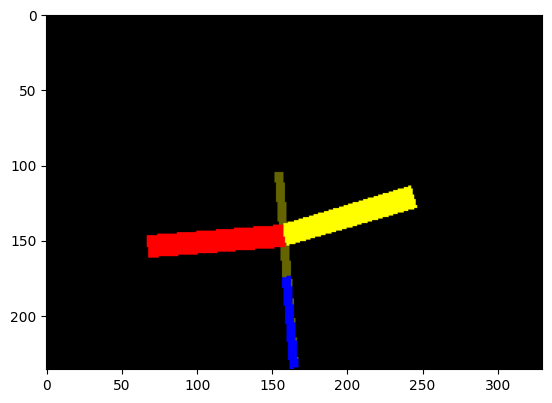

In [834]:
plt.imshow(combined[:, :, :, 100])

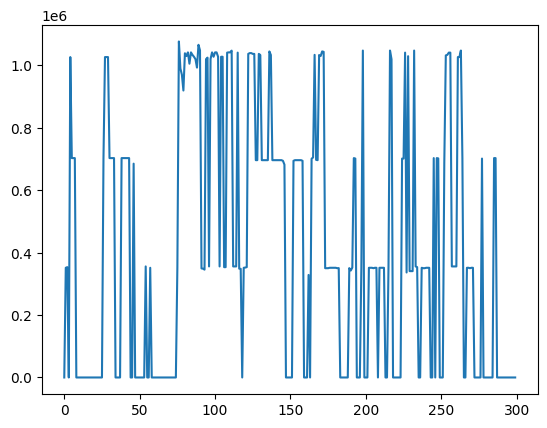

In [816]:
plt.plot(viz_cross.sum(axis = (0, 1, 2)))

In [886]:
import numpy as np

# Replace 'your_file.npy' with the actual file path
array2 = np.load("/workspace/test_results/cam2_"+current_image_path+".npy")



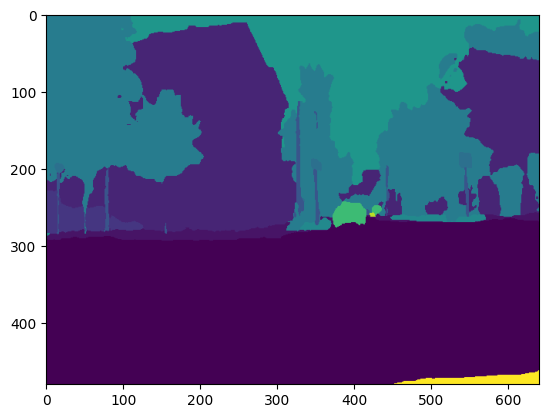

In [932]:
n = 220

plt.imshow(array1[n])

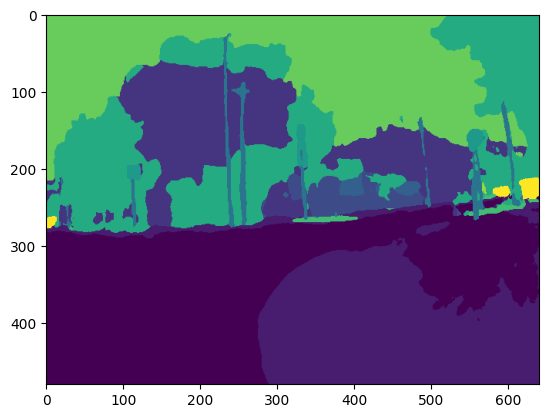

In [933]:
plt.imshow(array2[n])

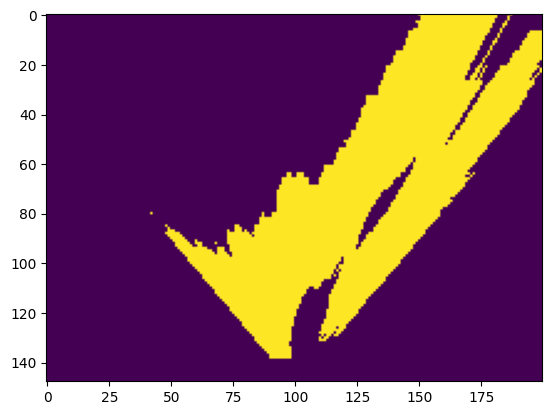

In [934]:
plt.imshow(bev_tensor2[:, :, n])

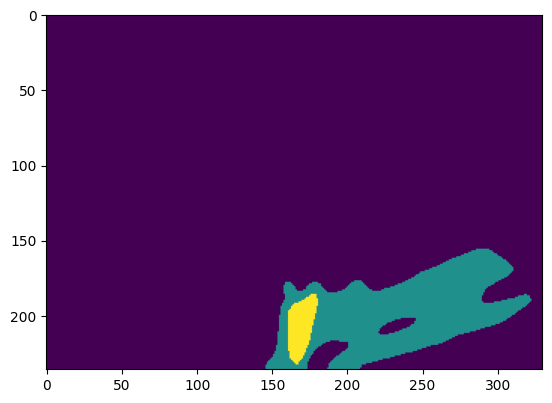

In [935]:
plt.imshow(denoised[:, :, n])

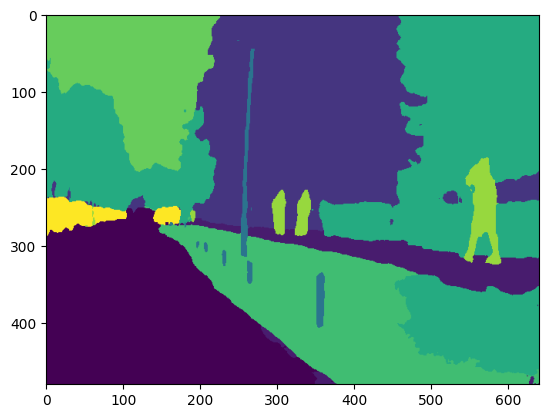

In [780]:
plt.imshow(array2[200])

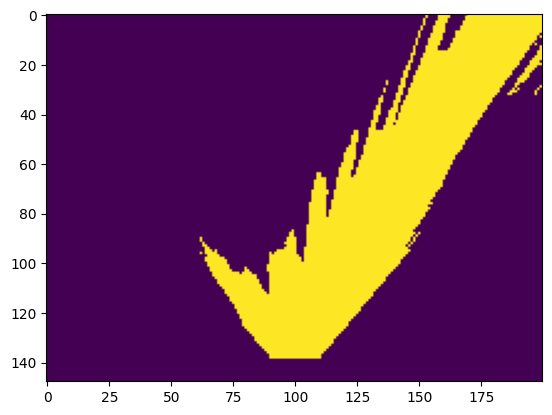

In [782]:
plt.imshow(bev_tensor2[:, :, 200])

In [19]:
import numpy as np
import cv2
from dataclasses import dataclass
from scipy.ndimage import gaussian_filter1d

# ------------------ small utils ------------------
def make_rotating_rect_tensor(
    H=236, W=330, n=12, *,
    length=120,
    thickness=12
) -> np.ndarray:
    """
    Create a tensor of shape (H, W, n) with one filled rectangle per slice.
    The rectangle is anchored at the bottom-center and rotates from left to right.
    """
    assert n >= 2, "Need at least two layers to interpolate angles."
    T = np.zeros((H, W, n), dtype=np.uint8)

    x0, y0 = W // 2, H - 1  # Anchor at bottom-center

    for i in range(n):
        theta_deg = 180.0 - i * (180.0 / (n - 1))  # from 180° to 0°
        theta = np.deg2rad(theta_deg)

        # direction vector
        dx = np.cos(theta)
        dy = -np.sin(theta)  # image coords: y down → invert sin

        x1 = x0 + length * dx
        y1 = y0 + length * dy

        # normal vector for thickness
        nx = -dy
        ny = dx

        half_t = thickness / 2.0

        p0 = np.array([x0, y0], dtype=np.float32)
        p1 = np.array([x1, y1], dtype=np.float32)
        nvec = np.array([nx, ny], dtype=np.float32)

        polygon = np.stack([
            p0 + nvec * half_t,
            p0 - nvec * half_t,
            p1 - nvec * half_t,
            p1 + nvec * half_t
        ]).astype(np.int32)

        canvas = np.zeros((H, W), dtype=np.uint8)
        cv2.fillPoly(canvas, [polygon], 1)
        T[:, :, i] = canvas

    return T



def decreasing_positive_quadratic(n: int, k: float = 0.6) -> np.ndarray:
    """
    Center-heavy bias in [~(1-k), 1]. k in [0,1]. Peak at center.
    """
    t = np.linspace(-1.0, 1.0, max(1, int(n)), dtype=np.float32)
    bias = 1.0 - k * (t ** 2)
    return np.clip(bias, 0.0, 1.0)

def rotate_shift_sum(img1, img2, angle_deg=-35.0, hor_shift_px=-40):
    """
    Rotate img1 by +angle and shift LEFT (negative), rotate img2 by -angle and shift RIGHT (positive).
    Sum results on a canvas that fits both.
    Inputs can be 0/1 or 0..255 (H,W) or (H,W,1/3).
    Returns: float32 or uint8, shape (H_out, W_out)
    """
    assert img1.shape == img2.shape, "Frames must have same size"
    H, W = img1.shape[:2]
    is_color = (img1.ndim == 3)
    C = img1.shape[2] if is_color else 1

    img1_f = img1.astype(np.float32)
    img2_f = img2.astype(np.float32)

    center = (W / 2.0, H / 2.0)
    M1 = cv2.getRotationMatrix2D(center, +angle_deg, 1.0)
    M2 = cv2.getRotationMatrix2D(center, -angle_deg, 1.0)

    M1[0, 2] += hor_shift_px  # left if negative
    M2[0, 2] -= hor_shift_px  # right if negative above

    def corners_after(M):
        cs = np.array([[0,0],[W,0],[W,H],[0,H]], dtype=np.float32)
        ones = np.ones((4,1), dtype=np.float32)
        cs_h = np.hstack([cs, ones])
        return (M @ cs_h.T).T

    c1 = corners_after(M1)
    c2 = corners_after(M2)
    allc = np.vstack([c1, c2])
    mn = np.floor(allc.min(axis=0)).astype(int)
    mx = np.ceil(allc.max(axis=0)).astype(int)
    out_W, out_H = (mx - mn)[0], (mx - mn)[1]

    shift_x, shift_y = -mn[0], -mn[1]
    M1[:, 2] += shift_x; M2[:, 2] += shift_x
    M1[1, 2] += shift_y; M2[1, 2] += shift_y

    dsize = (out_W, out_H)
    border_val = 0 if not is_color else (0,) * C
    w1 = cv2.warpAffine(img1_f, M1, dsize, flags=cv2.INTER_LINEAR, borderValue=border_val)
    w2 = cv2.warpAffine(img2_f, M2, dsize, flags=cv2.INTER_LINEAR, borderValue=border_val)
    S = w1 + w2
    return np.clip(S, 0, 255).astype(img1.dtype) if np.issubdtype(img1.dtype, np.integer) else S

def denoise_frame(frame_01: np.ndarray, kernel_size=4, blur_ksize=11, blur_sigma=6.0) -> np.ndarray:
    """
    Light morph + blur on a single 2D binary-ish frame (0/1 or 0/255). Returns uint8 in {0,255}.
    (Uses erode->dilate then Gaussian blur.)
    """
    img = (frame_01 > 0).astype(np.uint8) * 255
    k = cv2.getStructuringElement(cv2.MORPH_RECT, (kernel_size, kernel_size))
    er = cv2.erode(img, k)
    di = cv2.dilate(er, k)
    bl = cv2.GaussianBlur(di, (blur_ksize, blur_ksize), blur_sigma)
    return bl

def _group_contiguous(idxs: np.ndarray):
    if idxs.size == 0: return []
    idxs = np.sort(idxs)
    groups = []
    start = prev = idxs[0]
    for x in idxs[1:]:
        if x == prev + 1:
            prev = x
        else:
            groups.append(np.arange(start, prev + 1))
            start = prev = x
    groups.append(np.arange(start, prev + 1))
    return groups

def _resample_scores(scores: np.ndarray, out_len: int) -> np.ndarray:
    """Linear resample scores from len M_road to M_small to build a same-length bias."""
    M = len(scores)
    if M == out_len: return scores.copy()
    x_in = np.linspace(0, M - 1, M, dtype=np.float32)
    x_out = np.linspace(0, M - 1, out_len, dtype=np.float32)
    return np.interp(x_out, x_in, scores).astype(np.float32)

# ------------------ streaming state ------------------

@dataclass
class ProcessingState:
    """Carry temporal state between calls."""
    sel_last_road: np.ndarray | None = None   # (M_road,) one-hot smoothed memory
    last_best_road_idx: int | None = None

# ------------------ per-frame processor ------------------

def process_two_bev_frames(
    cam1_bev: np.ndarray,                 # (H, W) 0/1 or 0/255
    cam2_bev: np.ndarray,                 # (H, W) same shape as cam1_bev
    flower_tensor_road: np.ndarray,       # (H, W, M_road) uint8/bool masks
    flower_tensor_collision: np.ndarray,  # (H, W, M_small)
    state: "ProcessingState" | None = None,
    *,
    # combine params:
    combine_angle_deg: float = -35.0,
    combine_hshift_px: int = -40,
    # scoring/smoothing:
    centre_bias_coefficient: float = 0.6,
    sigma_scores: float = 4.0,
    remembrance: float = 8.0,
    residual_sigma: float = 16.0,
    convergent_with_road: float = 5.0,
    # thresholds:
    road_min_abs: float = 40.0,
    road_min_frac_of_max: float = 0.10,
    collision_min_abs: float = 300.0,
    collision_min_frac_of_max: float = 0.30,
    small_top_k: int = 1,
    # visualization colors:
    road_color=(100, 255, 100),
    selected_road_color=(0, 255, 255),
    small_color=(0, 0, 255),
    # denoise params:
    morph_kernel: int = 4,
    blur_ksize: int = 11,
    blur_sigma: float = 6.0
):
    """
    Returns:
      viz_img:     (Hc, Wc, 3) uint8 visualization for this frame
      denoised_u8: (Hc, Wc)    uint8 denoised (morph+blur) image of the combined frame
      new_state:   ProcessingState for next call
      result:      dict with fields (best_road_idx, best_small_idxs, kept_indices, combined_frame, road_scores, small_scores_biased)
    """
    H, W, M_road = flower_tensor_road.shape
    _, _, M_small = flower_tensor_collision.shape

    # 1) Combine two BEV frames into one canvas
    f1 = (cam1_bev > 0).astype(np.uint8)
    f2 = (cam2_bev > 0).astype(np.uint8)
    combined = rotate_shift_sum(f2, f1, angle_deg=combine_angle_deg, hor_shift_px=combine_hshift_px)
    combined01 = (combined > 0).astype(np.uint8)

    # 2) Denoise
    den = denoise_frame(combined01, kernel_size=morph_kernel, blur_ksize=blur_ksize, blur_sigma=blur_sigma)
    denoised_u8 = den  # <- will be returned
    frame = (den > 0).astype(np.float32)  # binary for scoring

    # 3) Prepare/restore state
    if state is None or state.sel_last_road is None or len(state.sel_last_road) != M_road:
        sel_last = np.zeros((M_road,), dtype=np.float32)
    else:
        sel_last = state.sel_last_road.astype(np.float32)

    # 4) ROAD scores
    road_scores = np.sum(frame[:, :, None] * flower_tensor_road.astype(np.float32), axis=(0, 1))  # (M_road,)
    road_scores *= decreasing_positive_quadratic(M_road, centre_bias_coefficient).astype(np.float32)
    road_scores = gaussian_filter1d(road_scores, sigma=sigma_scores)

    if remembrance > 0.0:
        residual_smoothed = gaussian_filter1d(sel_last, sigma=residual_sigma)
        road_scores = road_scores * (1.0 + remembrance * residual_smoothed)

    best_road_idx = int(np.argmax(road_scores))
    road_gate = max(road_min_abs, road_min_frac_of_max * (float(road_scores.max()) if road_scores.size else 0.0))
    draw_road = bool(road_scores[best_road_idx] >= road_gate)

    # update memory (one-hot)
    sel_last[:] = 0.0
    sel_last[best_road_idx] = 1.0

    # 5) COLLISION scores (independent) + bias toward road scores resampled to small grid
    small_scores = np.sum(frame[:, :, None] * flower_tensor_collision.astype(np.float32), axis=(0, 1))  # (M_small,)
    small_scores = gaussian_filter1d(small_scores, sigma=sigma_scores)
    road_scores_small = _resample_scores(road_scores, M_small)
    bias = 1.0 + (road_scores_small / (road_scores_small.sum() + 1e-8)) * convergent_with_road
    small_scores_biased = small_scores * bias

    coll_gate = max(collision_min_abs, collision_min_frac_of_max * (float(small_scores_biased.max()) if small_scores_biased.size else 0.0))
    valid_small = np.where(small_scores_biased >= coll_gate)[0]

    if valid_small.size > 0:
        k = int(max(1, min(small_top_k, valid_small.size)))
        valid_scores = small_scores_biased[valid_small]
        sel = np.argpartition(-valid_scores, kth=k-1)[:k]
        best_small_idxs = valid_small[sel]
        best_small_idxs = best_small_idxs[np.argsort(-small_scores_biased[best_small_idxs])]
    else:
        best_small_idxs = np.array([], dtype=int)

    # 6) Visualization (groups -> strongest angle, intensity ∝ group size)
    kept_indices = np.where(road_scores >= road_gate)[0]
    viz_img = np.zeros((*frame.shape, 3), dtype=np.uint8)

    if kept_indices.size > 0:
        groups = _group_contiguous(kept_indices)
        max_len = max(len(g) for g in groups) if groups else 1
        base_col = np.array(road_color, dtype=np.float32)
        for g in groups:
            g = np.array(g, dtype=int)
            g_best = g[np.argmax(road_scores[g])]
            best_mask = flower_tensor_road[:, :, g_best].astype(bool)
            factor = 0.5 + 0.5 * (len(g) / max_len)  # [0.5, 1.0]
            col = np.clip(np.round(base_col * factor), 0, 255).astype(np.uint8)
            viz_img[best_mask] = col

    if draw_road:
        sel_mask = flower_tensor_road[:, :, best_road_idx].astype(bool)
        viz_img[sel_mask] = np.array(selected_road_color, dtype=np.uint8)

    if best_small_idxs.size > 0:
        if best_small_idxs.size == 1:
            small_mask = flower_tensor_collision[:, :, best_small_idxs[0]].astype(bool)
            viz_img[small_mask] = np.array(small_color, dtype=np.uint8)
        else:
            small_mask_union = np.any(flower_tensor_collision[:, :, best_small_idxs].astype(bool), axis=2)
            viz_img[small_mask_union] = np.array(small_color, dtype=np.uint8)

    # 7) Pack results & state
    new_state = ProcessingState(sel_last_road=sel_last.copy(), last_best_road_idx=best_road_idx)
    result = {
        "best_road_idx": best_road_idx,
        "best_small_idxs": best_small_idxs,
        "kept_indices": kept_indices,
        "combined_frame": combined01,          # 0/1 combined
        "road_scores": road_scores,
        "small_scores_biased": small_scores_biased
    }

    # NEW: return denoised image as the second item
    return viz_img, denoised_u8, new_state, result


    
# one-time: build flower tensors (H, W must match your BEV frame after rotate/shift)
# flower_tensor_road  = make_rotating_rect_tensor(H, W, M_road, length=.., thickness=..)
# flower_tensor_collision = make_rotating_rect_tensor(H, W, M_small, length=.., thickness=..)
list_viz = []
list_denoised = []
list_combined = []


def combine_viz_and_denoised(viz_img: np.ndarray, denoised_frame: np.ndarray, alpha_viz: float = 0.85) -> np.ndarray:
    """
    Alpha-blend viz over denoised background only where viz has content.
    viz_img:       (H, W, 3) uint8
    denoised_frame:(H, W)    uint8
    returns:       (H, W, 3) uint8
    """
    bg = cv2.cvtColor(denoised_frame, cv2.COLOR_GRAY2BGR)
    # mask where the viz has any color
    mask = (viz_img.sum(axis=2) > 0)
    out = bg.copy()
    if mask.any():
        out[mask] = cv2.addWeighted(bg[mask], 1.0 - alpha_viz, viz_img[mask], alpha_viz, 0.0)
    return out





projector_left, grid_left = make_projector_and_grid(
    frame_shape=seg.shape,
    fx=300.0, fy=int(530/380*200),
    height_m=1.0,
    pitch_deg_down=0.0,
    meters_per_pixel=0.20,
    forward_range=(0.5, 30.0),
    lateral_range=(-20.0, 20.0),
)


projector_right, grid_right = make_projector_and_grid(
    frame_shape=seg.shape,
    fx=380.0, fy=530.0,
    height_m=1.0,
    pitch_deg_down=0.0,
    meters_per_pixel=0.20,
    forward_range=(0.5, 30.0),
    lateral_range=(-20.0, 20.0),
)

flower_tensor_road = make_rotating_rect_tensor(H=236, W=330, n= 100, length=130, thickness=5)
flower_tensor_collision = make_rotating_rect_tensor(H=236, W=330, n= 100, length=60, thickness=5)


state = None

right_frames_list = []
left_frames_list = []

for t in range(N):
    cam1 = left_camera[t]       # (H, W) uint8 0/255
    cam2 = right_camera[t]           # (H, W) uint8 0/255
    
    bev_frame_left = npy_frame_to_bev(cam1, projector_left, grid_left, road_label=0)
    bev_frame_right = npy_frame_to_bev(cam2, projector_right, grid_right, road_label=0)

    left_frames_list.append(bev_frame_left)
    right_frames_list.append(bev_frame_right)

    
    viz_img, denoised_frame, state, res = process_two_bev_frames(
        bev_frame_left, 
        bev_frame_right,
        flower_tensor_road, flower_tensor_collision,
        state,
        combine_angle_deg=-35.0,
        combine_hshift_px=40,
        centre_bias_coefficient=0.6,
        sigma_scores=4.0,
        remembrance=8.0,
        residual_sigma=16.0,
        convergent_with_road=5.0,
        road_min_abs=40,
        road_min_frac_of_max=0.10,
        collision_min_abs=300,
        collision_min_frac_of_max=0.30,
        small_top_k=1,
        road_color=(100,255,100),
        selected_road_color=(0,255,255),
        small_color=(0,0,255),
        morph_kernel=4,
        blur_ksize=11,
        blur_sigma=6.0
    )
    list_combined.append(combine_viz_and_denoised(viz_img, denoised_frame))
    list_denoised.append(denoised_frame)
    list_viz.append(viz_img)
    # viz_img is (Hc, Wc, 3) uint8 — write to video or display


In [ ]:
cam1

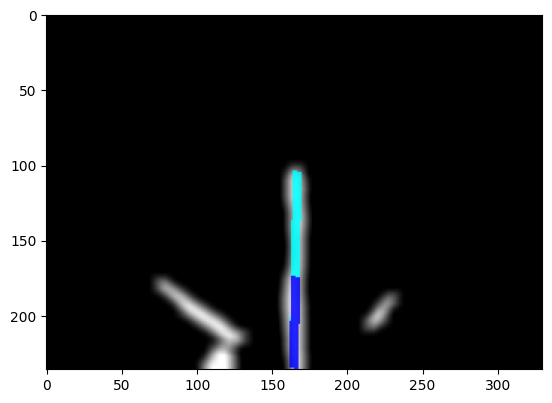

In [29]:
plt.imshow(list_combined[150])

In [30]:
seg.shape

(480, 640)

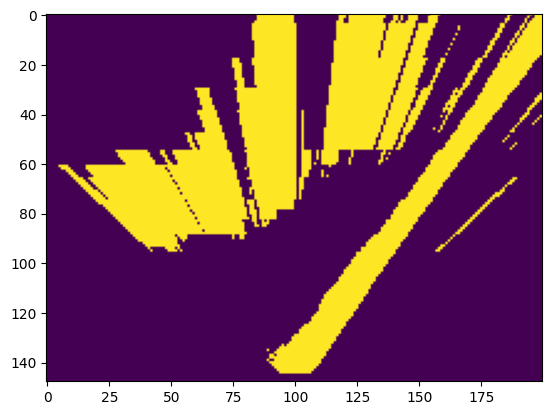

In [22]:
plt.imshow(left_frames_list[20])

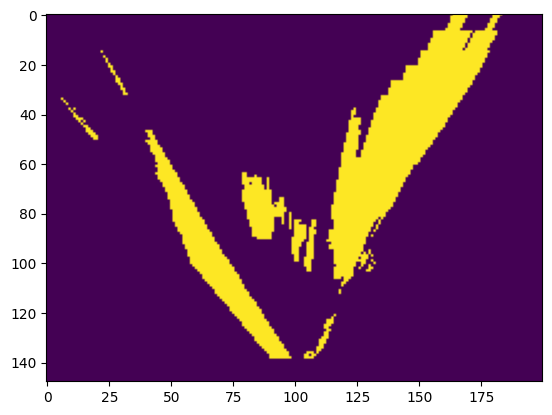

In [21]:
plt.imshow(right_frames_list[20])

In [1012]:
t2v(list_to_numpy_tensor(list_combined), "combined_road_and_denoised.mp4")

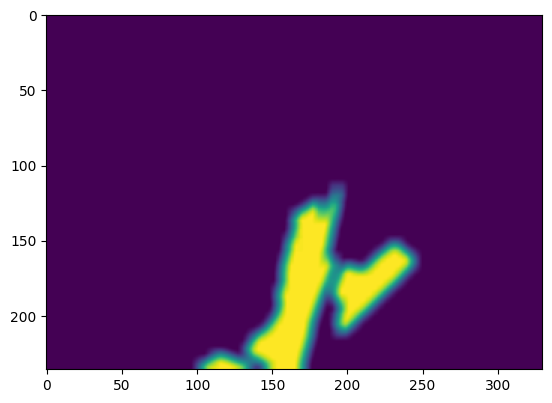

In [987]:
plt.imshow(list_denoised[200])

In [991]:
list_denoised[200].max()

255

In [753]:
np.argmax(viz_cross.sum(axis = (0, 1, 2)))

109

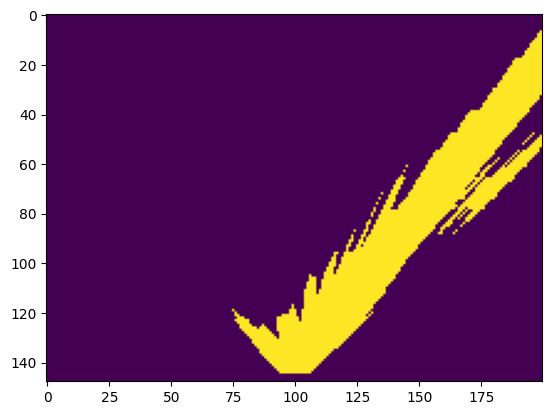

In [772]:
plt.imshow(bev_tensor1[:, :, 200])

In [744]:
plt.plot(gaussian_filter1d(lista__[50][: ,0], sigma=2))


IndexError: list index out of range

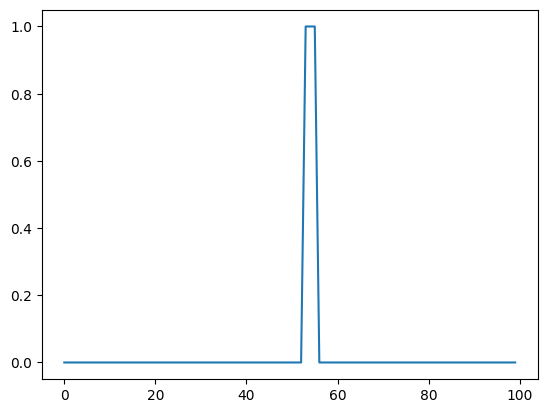

In [560]:
plt.plot(lista__[50][: ,0])

In [553]:
lista__[50].shape

(100, 1)

In [ ]:
roads_tensor.sum()

In [493]:
roads_tensor.sum()

166587

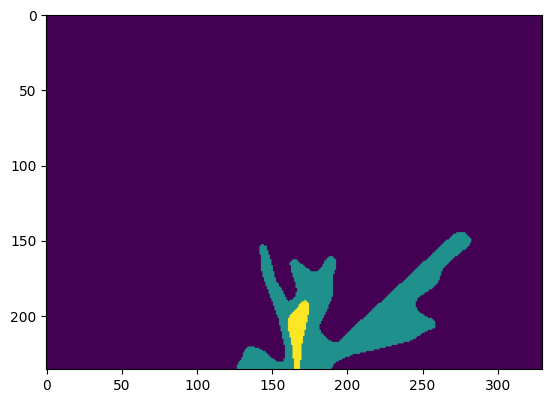

In [494]:
plt.imshow(denoised[:, :, 0])

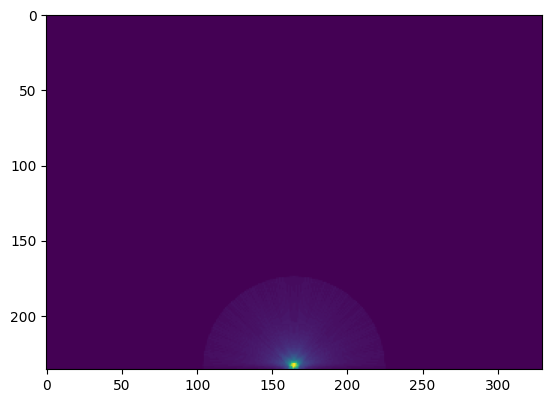

In [440]:
plt.imshow(flower_tensor_collision.sum(axis = 2))

In [346]:
np.sum(roads)

0

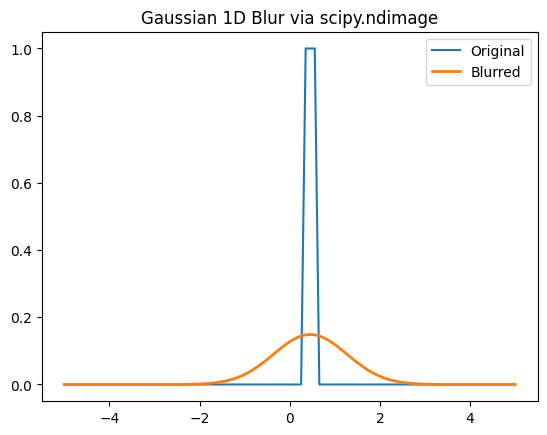

In [576]:
from scipy.ndimage import gaussian_filter1d
import numpy as np
import matplotlib.pyplot as plt

# Sample signal
x = np.linspace(-5, 5, 100)
signal = np.float64(lista__[50])[:, 0]

#signal[50:52] = 1

# Apply Gaussian blur
blurred = gaussian_filter1d(signal, sigma=8)

# Plot
plt.plot(x, signal, label="Original")
plt.plot(x, blurred, label="Blurred", linewidth=2)
plt.legend()
plt.title("Gaussian 1D Blur via scipy.ndimage")
plt.show()

In [573]:
x.shape

(100,)

In [572]:
signal.shape

(100, 1)

In [294]:
flower_tensor.shape

(236, 330, 100)

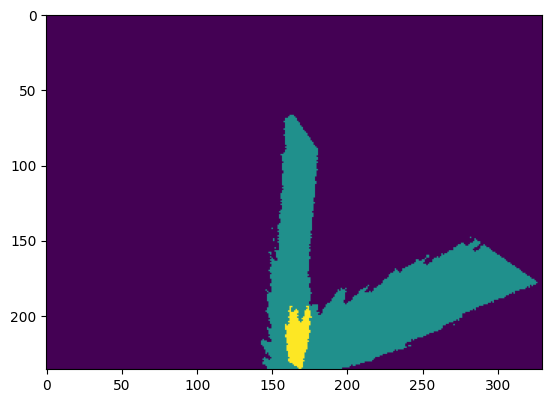

In [288]:
plt.imshow(tensor_hwn[:, :, n])

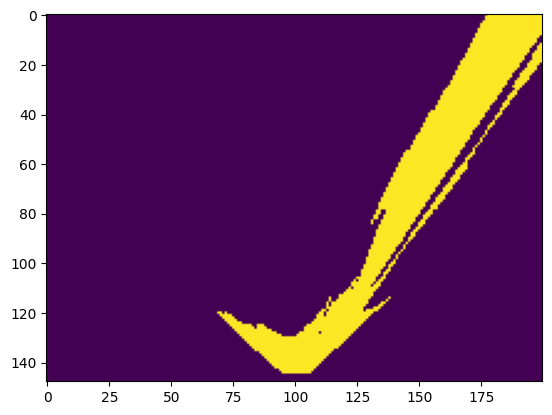

In [487]:
plt.imshow(bev_tensor1[:, :, 30])

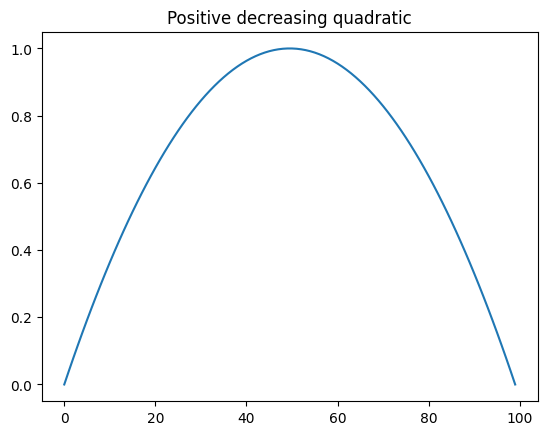

In [313]:
import numpy as np
import matplotlib.pyplot as plt

def decreasing_positive_quadratic(n=50, k=1):
    """
    Returns an array of length n representing a quadratic curve
    that is positive, centered, and strictly decreasing.
    """
    # Symmetric x around 0
    x = np.linspace(0, n, n)   # take only the left side
    y = ((-((x-(n/2)) / k)**2) + (n)**2) / n**2              # quadratic shifted up so it's always positive
    return y

arr = decreasing_positive_quadratic(100, k=0.5)


plt.plot(arr)
plt.title("Positive decreasing quadratic")
plt.show()


In [146]:
sel

NameError: name 'sel' is not defined

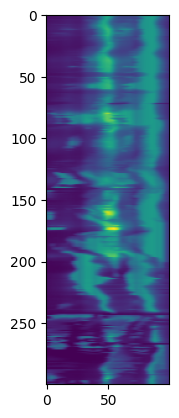

In [246]:
plt.imshow(overlap)

In [110]:
recon.sum()

0

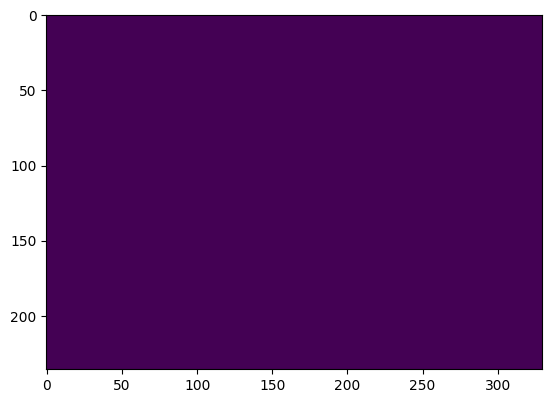

In [105]:
plt.imshow(recon[: ,:, 0])

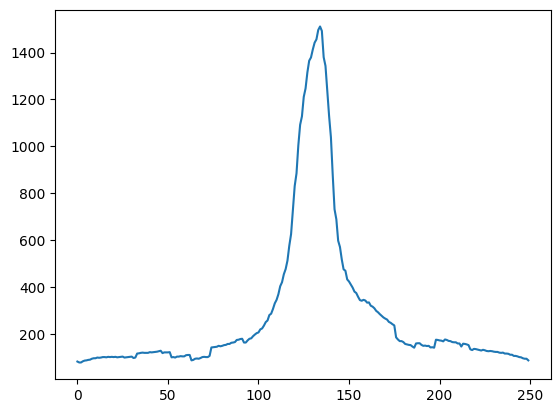

In [60]:
plt.plot(result)

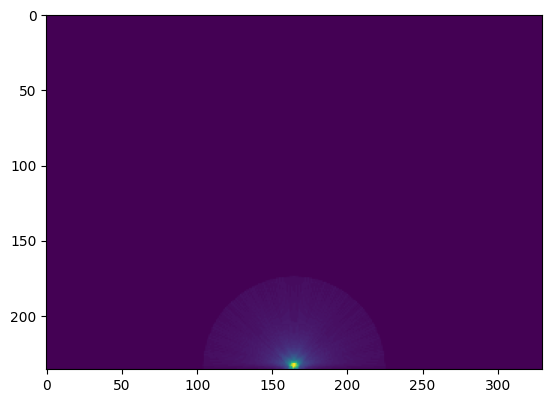

In [383]:
plt.imshow(flower_tensor.sum(axis = 2))

In [35]:
middle_square = np.zeros((236, 330))

In [36]:
middle_square[110:126, 158:172] = 1

In [40]:
np.multiply(middle_square, flower_tensor[:, :, 1]).sum()

0.0

In [33]:
result

array(63, dtype=uint8)

In [34]:
flower_tensor

array([[[0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        ...,
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0]],

       [[0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        ...,
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0]],

       [[0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        ...,
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0]],

       ...,

       [[0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        ...,
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0]],

       [[0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        ...,
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0]],

       [[0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        ...,
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0]]

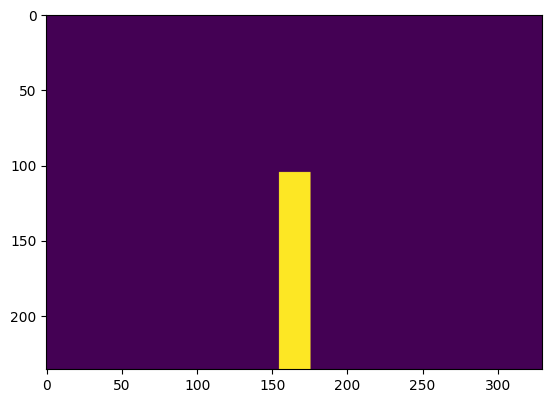

In [31]:
plt.imshow(flower_tensor[:, :, 2])

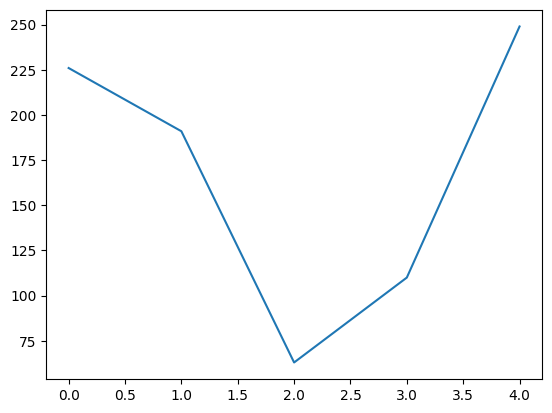

In [24]:
plt.plot(result)

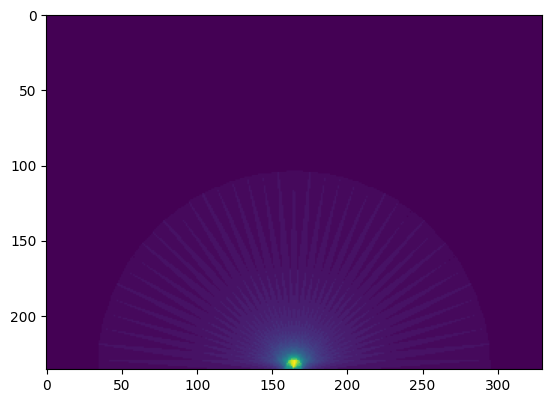

In [13]:
plt.imshow(flower_tensor.sum(axis = 2))

In [16]:
te.shape

(236, 330, 300)

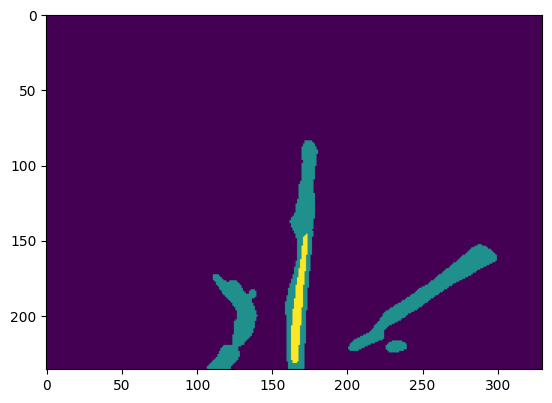

In [187]:
plt.imshow(denoised[:, :, 108])

In [62]:
np.max(tensor_hwn[:, :, 298])

2

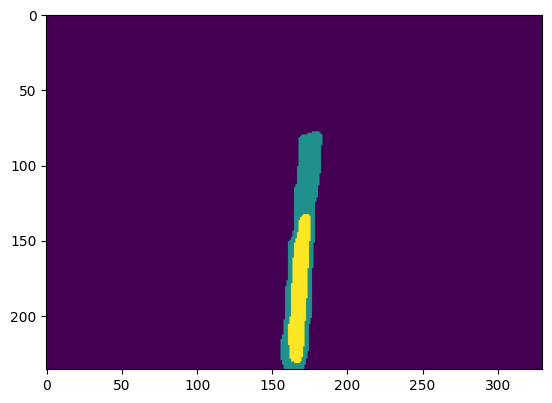

In [171]:
plt.imshow(denoised[:, :, 150])